# PadChest224 — Pipeline Optimisé (EfficientNet-B4 + CLAHE + Mixup + TTA + Seuils Optimaux)

**Pathologies cibles :** normal, copd signs, cardiomegaly, pleural effusion, interstitial pattern, alveolar pattern, nodule, atelectasis, hilar enlargement, pulmonary fibrosis, tuberculosis sequelae, rib fracture, pneumothorax, mediastinal mass

**Optimisations intégrées :**
- CLAHE dans le Dataset pour améliorer le contraste des X-rays
- Mixup multi-label dans le train loop
- Warmup LR (3 epochs) + ReduceLROnPlateau
- EfficientNet-B4 (feat_dim=1792) au lieu de DenseNet121
- Seuils optimaux par classe sur val set
- TTA (Test-Time Augmentation) à l'inférence

## 0. Imports & Configuration globale

In [2]:
import os
import ast
import cv2
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    accuracy_score, classification_report, confusion_matrix
)
import torchvision.transforms as T

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Chemins ───────────────────────────────────────────────────────────────────
CSV_PATH    = "/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv"
IMAGES_PATH = "/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224"

# ── Pathologies cibles (14 classes) ───────────────────────────────────────────
TARGET_DISEASES = [
    'normal', 'copd signs', 'cardiomegaly', 'pleural effusion',
    'interstitial pattern', 'alveolar pattern', 'nodule', 'atelectasis',
    'hilar enlargement', 'pulmonary fibrosis', 'tuberculosis sequelae',
    'rib fracture', 'pneumothorax', 'mediastinal mass'
]

NUM_CLASSES = len(TARGET_DISEASES)
print(f"Nombre de pathologies cibles : {NUM_CLASSES}")
print("Pathologies :", TARGET_DISEASES)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = DEVICE.type
USE_AMP    = DEVICE.type == 'cuda'
print(f"\nDevice : {DEVICE}  |  AMP : {USE_AMP}")

Nombre de pathologies cibles : 14
Pathologies : ['normal', 'copd signs', 'cardiomegaly', 'pleural effusion', 'interstitial pattern', 'alveolar pattern', 'nodule', 'atelectasis', 'hilar enlargement', 'pulmonary fibrosis', 'tuberculosis sequelae', 'rib fracture', 'pneumothorax', 'mediastinal mass']

Device : cuda  |  AMP : True


## Phase 1 — Exploration du dataset (EDA + Visualisations)

### 1.1 Chargement et aperçu du CSV

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print("Dataset Shape :", df.shape)
display(df.head())

Dataset Shape : (160861, 36)


,Index,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,25.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,10.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
3,3,113855343774216031107737439268243531979_3k951l...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,POSTEROANTERIOR,PA,...,8.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
4,4,113855343774216031107737439268243531979_3k951n...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,LATERAL,L,...,20.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']


### 1.2 Filtrage sur les 14 pathologies cibles

In [4]:
filtered_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        labels = ast.literal_eval(row['Labels'])
        labels = [label.lower().strip() for label in labels]
        matched_labels = [label for label in labels if label in TARGET_DISEASES]
        if len(matched_labels) > 0:
            row['FilteredLabels'] = matched_labels
            filtered_rows.append(row)
    except:
        continue

filtered_df = pd.DataFrame(filtered_rows)
print("\nFiltered Dataset Shape :", filtered_df.shape)

100%|██████████| 160861/160861 [00:49<00:00, 3238.96it/s]



Filtered Dataset Shape : (107116, 37)


### 1.3 Distribution des 14 pathologies (toutes images)

,Disease,Count
0,normal,50616
5,copd signs,23280
7,cardiomegaly,15028
4,pleural effusion,10026
3,interstitial pattern,7831
2,alveolar pattern,5739
10,nodule,3781
6,atelectasis,2905
11,hilar enlargement,1541
1,pulmonary fibrosis,1228


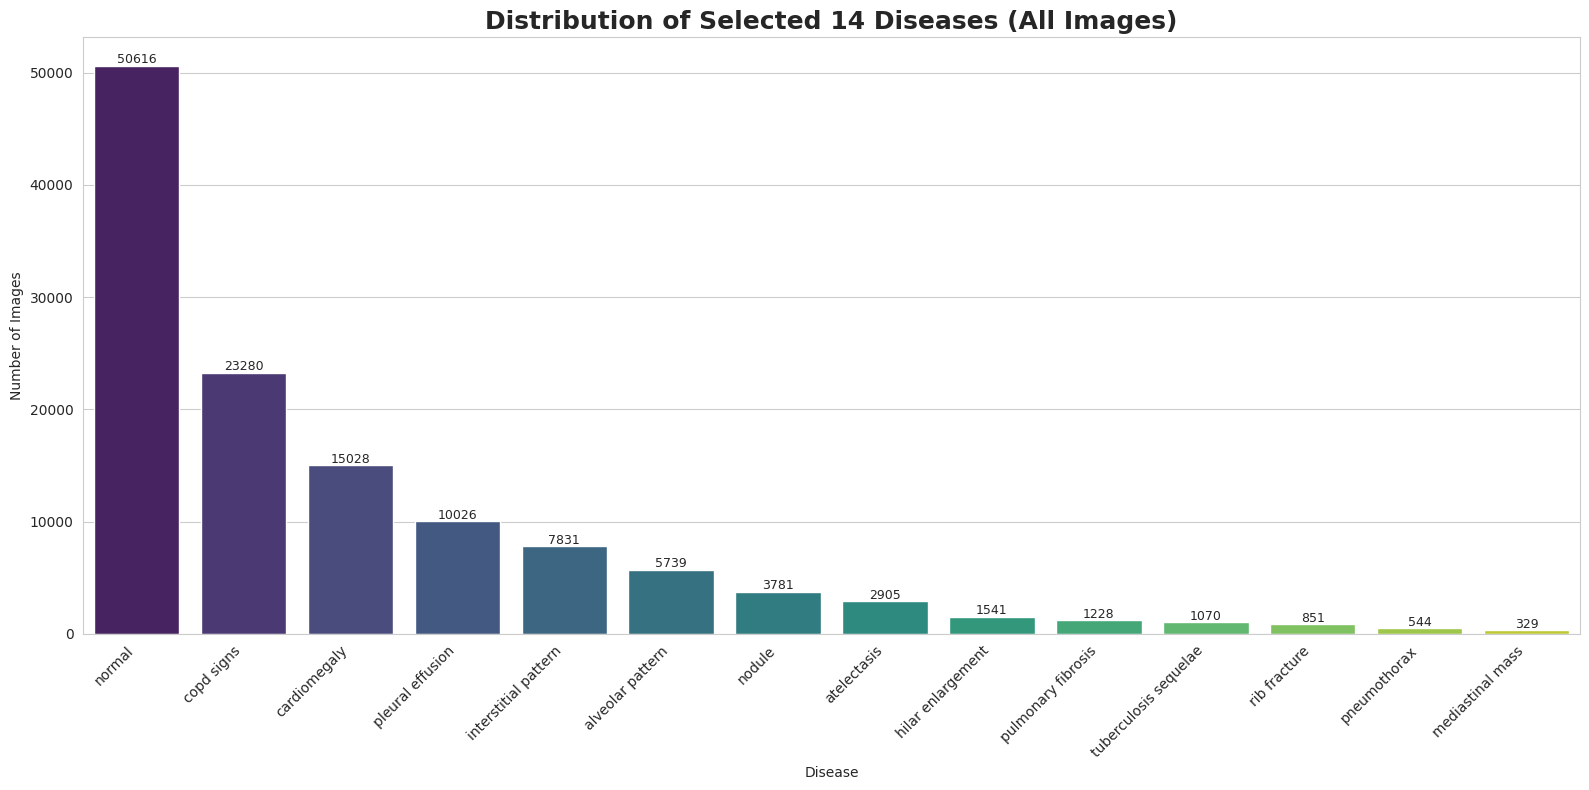

In [5]:
counter = Counter()
for labels in filtered_df['FilteredLabels']:
    counter.update(labels)

disease_counts = pd.DataFrame(
    counter.items(), columns=['Disease', 'Count']
).sort_values(by='Count', ascending=False)

display(disease_counts)

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=disease_counts, x='Disease', y='Count', palette='viridis')
for index, value in enumerate(disease_counts['Count']):
    plt.text(index, value + 200, str(value), ha='center', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Selected 14 Diseases (All Images)", fontsize=18, fontweight='bold')
plt.xlabel("Disease"); plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig('/kaggle/working/disease_distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Distribution mono-label

Single Label Dataset Shape : (92737, 37)


,Disease,Count
0,normal,50501
3,copd signs,17916
6,cardiomegaly,9271
2,pleural effusion,4511
5,interstitial pattern,2589
11,nodule,2169
9,alveolar pattern,1864
4,atelectasis,1014
10,hilar enlargement,725
7,tuberculosis sequelae,631


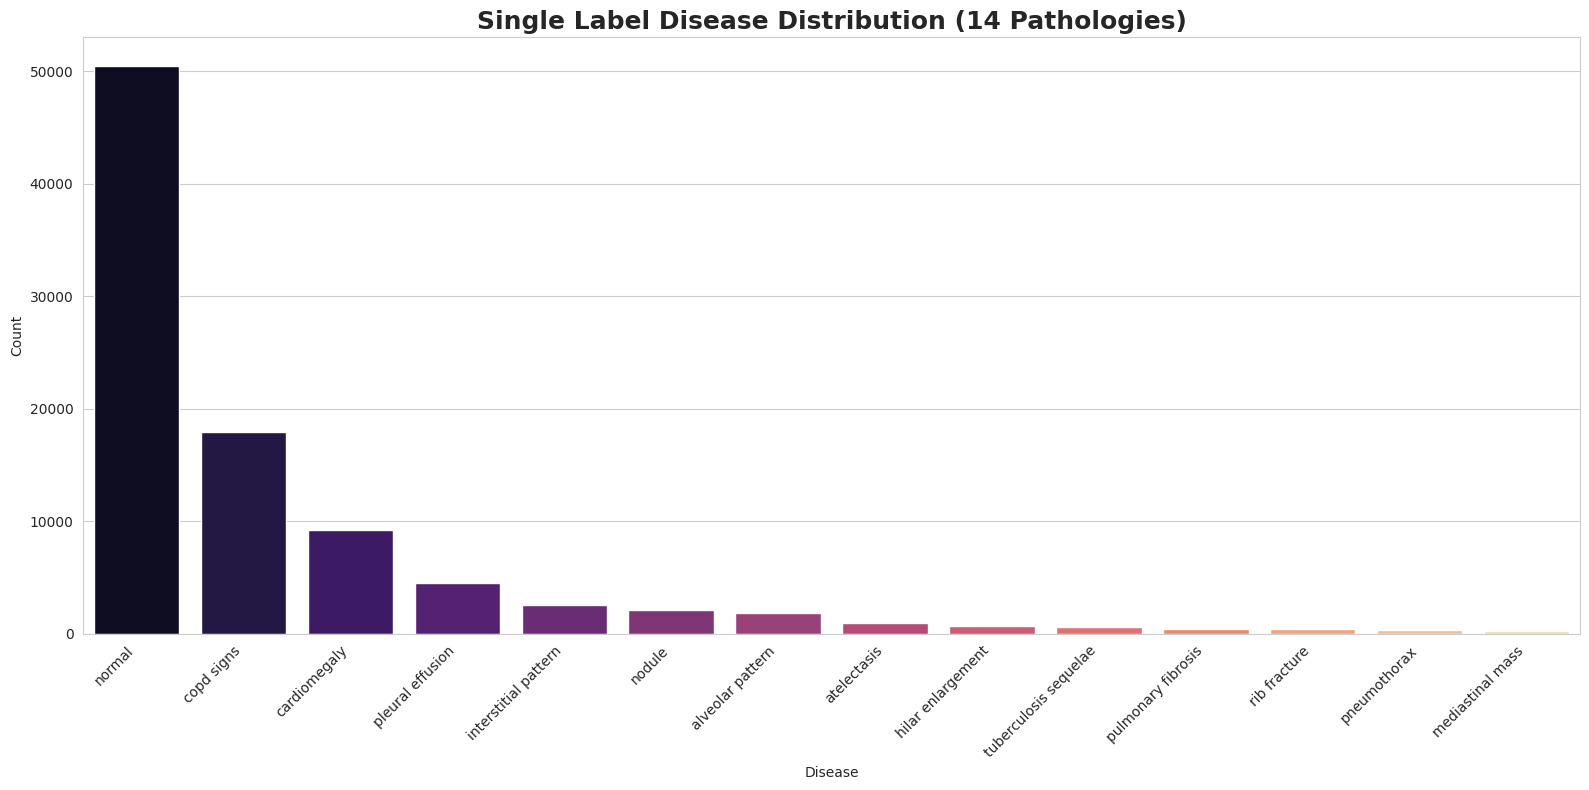

In [6]:
single_label_df = filtered_df[filtered_df['FilteredLabels'].apply(lambda x: len(x) == 1)]
print("Single Label Dataset Shape :", single_label_df.shape)

single_counter = Counter()
for labels in single_label_df['FilteredLabels']:
    single_counter.update(labels)

single_counts = pd.DataFrame(
    single_counter.items(), columns=['Disease', 'Count']
).sort_values(by='Count', ascending=False)

display(single_counts)

plt.figure(figsize=(16, 8))
sns.barplot(data=single_counts, x='Disease', y='Count', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Single Label Disease Distribution (14 Pathologies)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/disease_distribution_single.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Distribution démographique (sexe, naissance, projection)

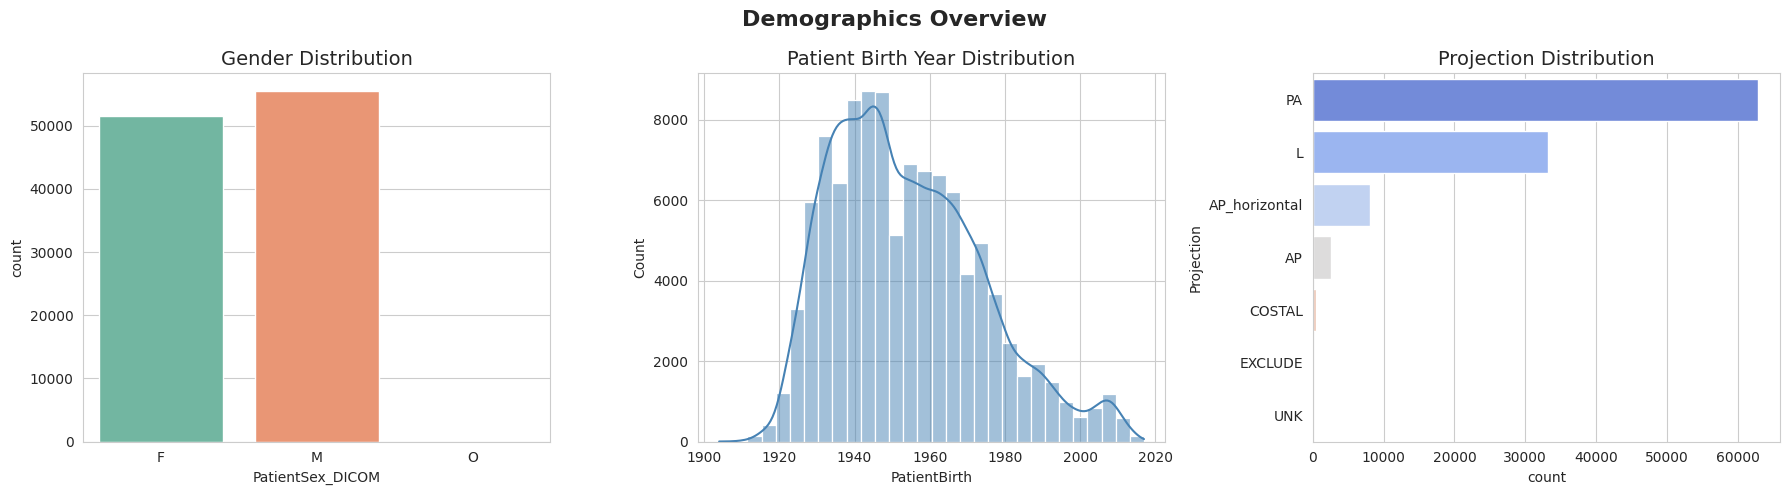

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'PatientSex_DICOM' in filtered_df.columns:
    sns.countplot(data=filtered_df, x='PatientSex_DICOM', palette='Set2', ax=axes[0])
    axes[0].set_title("Gender Distribution", fontsize=14)

if 'PatientBirth' in filtered_df.columns:
    sns.histplot(filtered_df['PatientBirth'].dropna(), bins=30, kde=True, ax=axes[1], color='steelblue')
    axes[1].set_title("Patient Birth Year Distribution", fontsize=14)

if 'Projection' in filtered_df.columns:
    proj_order = filtered_df['Projection'].value_counts().index
    sns.countplot(data=filtered_df, y='Projection', order=proj_order, palette='coolwarm', ax=axes[2])
    axes[2].set_title("Projection Distribution", fontsize=14)

plt.suptitle("Demographics Overview", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/demographics.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.6 Co-occurrence des pathologies (heatmap)

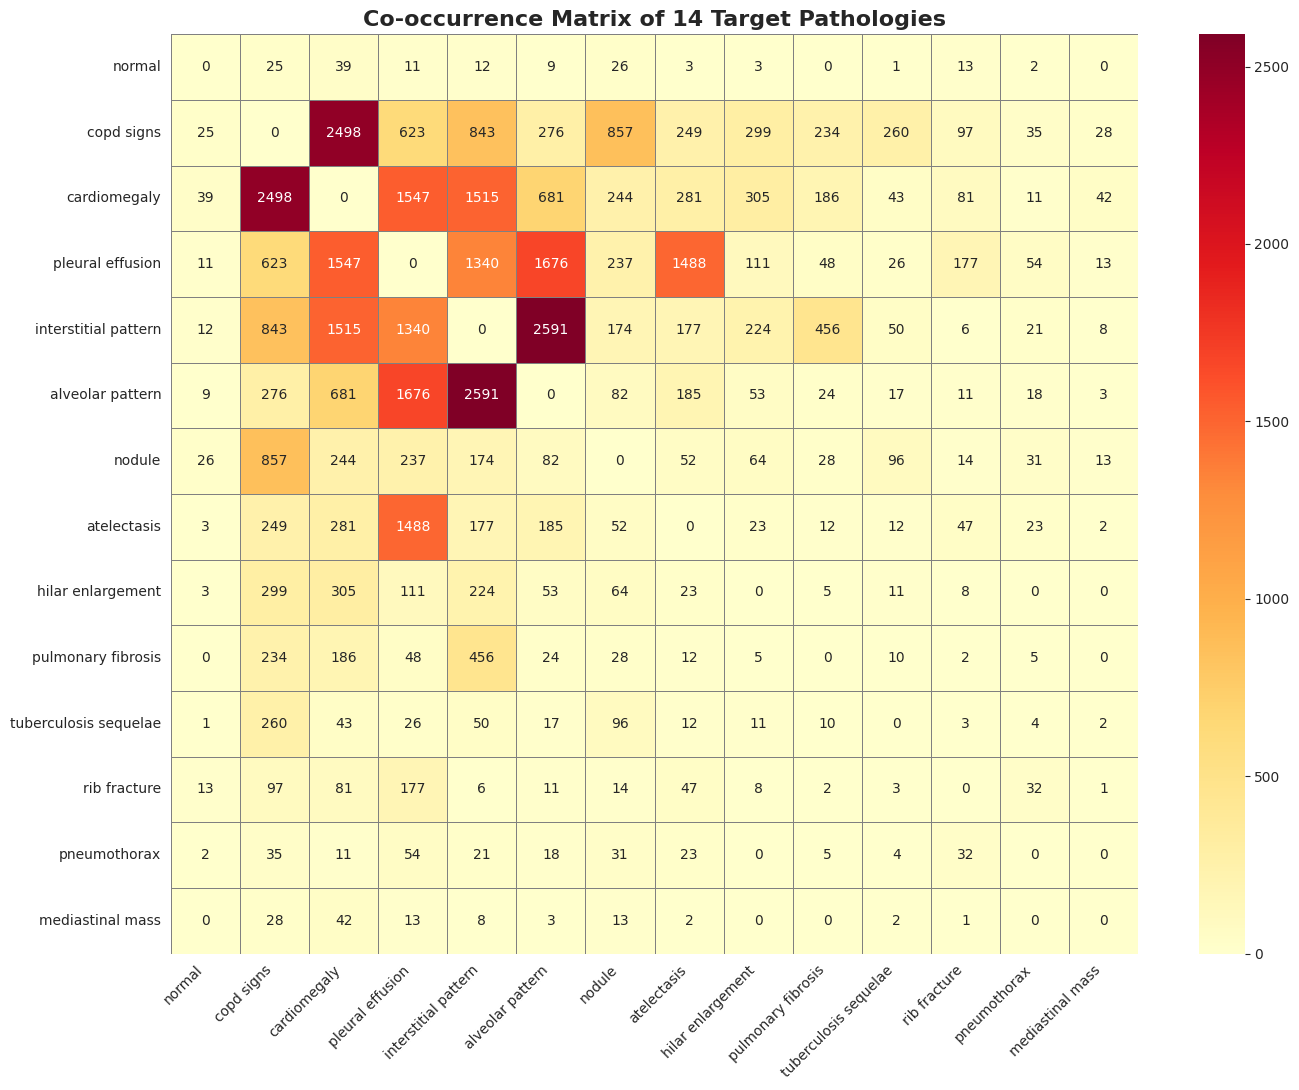

In [8]:
cooc = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

for labels in filtered_df['FilteredLabels']:
    idxs = [TARGET_DISEASES.index(l) for l in labels if l in TARGET_DISEASES]
    for i in idxs:
        for j in idxs:
            cooc[i, j] += 1

np.fill_diagonal(cooc, 0)
cooc_df = pd.DataFrame(cooc, index=TARGET_DISEASES, columns=TARGET_DISEASES)

plt.figure(figsize=(14, 11))
sns.heatmap(cooc_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='gray')
plt.title("Co-occurrence Matrix of 14 Target Pathologies", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/cooccurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7 Aperçu visuel — exemples d'images par pathologie

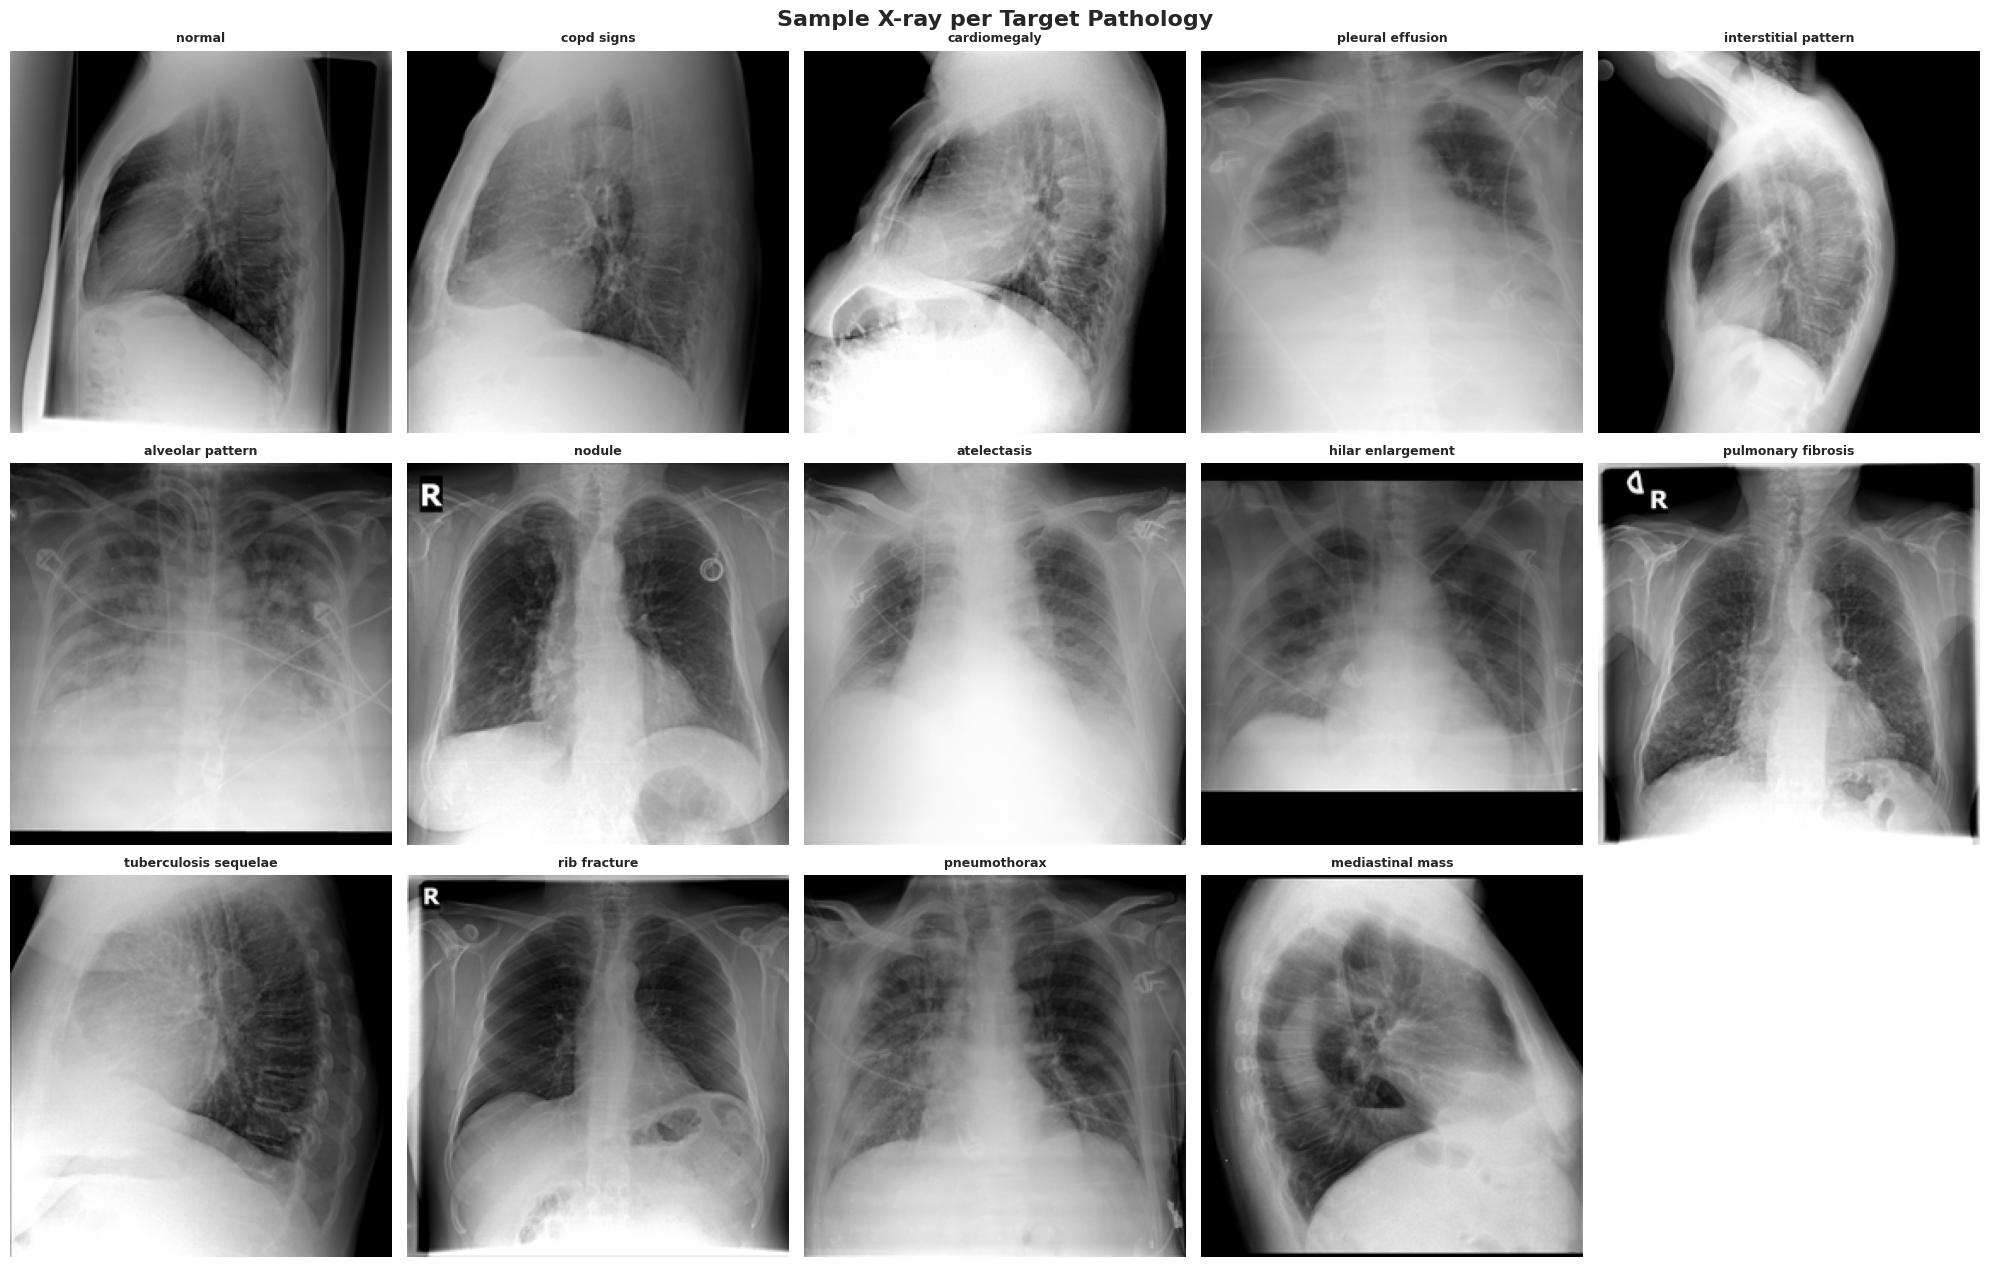

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(20, 13))
axes = axes.flatten()

shown = 0
for disease in TARGET_DISEASES:
    subset = filtered_df[filtered_df['FilteredLabels'].apply(lambda l: disease in l)]
    if len(subset) == 0:
        axes[shown].axis('off'); shown += 1; continue
    sample_row = subset.sample(1).iloc[0]
    try:
        img_path = os.path.join(IMAGES_PATH, sample_row['ImageID'])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[shown].imshow(img, cmap='gray')
        axes[shown].set_title(disease, fontsize=9, fontweight='bold')
        axes[shown].axis('off')
    except:
        axes[shown].axis('off')
    shown += 1

for i in range(shown, len(axes)):
    axes[i].axis('off')

plt.suptitle("Sample X-ray per Target Pathology", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images_per_disease.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 Distribution des tailles d'images et intensité pixel

100%|██████████| 1000/1000 [00:11<00:00, 87.38it/s]


,Width,Height
count,1000.0,1000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


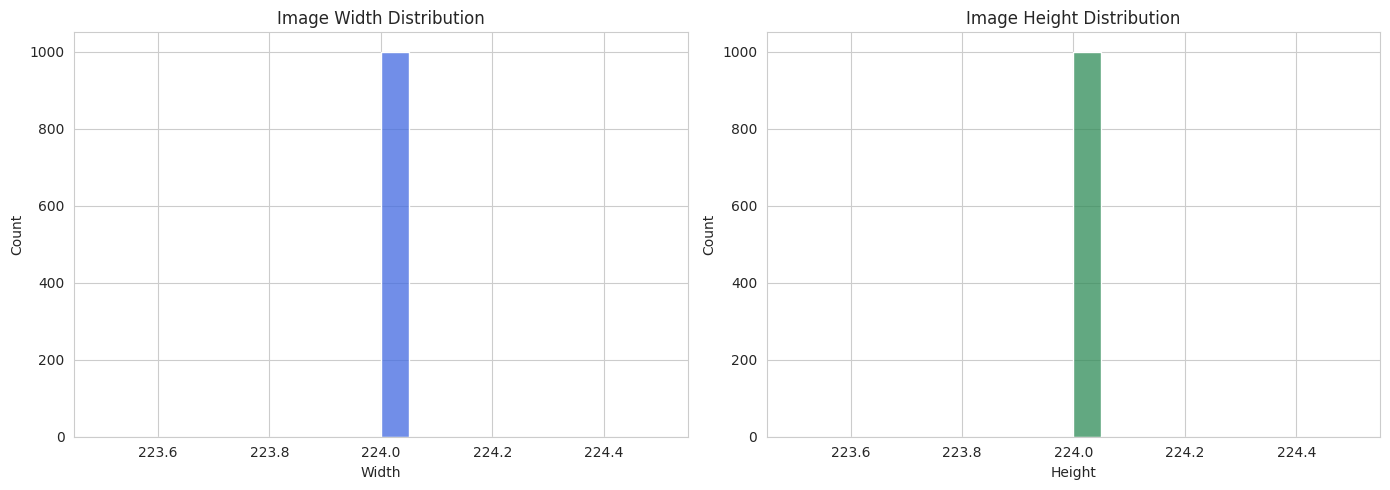

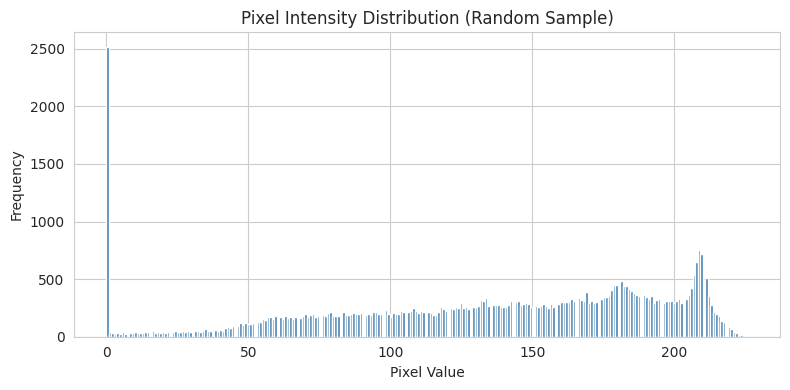

In [10]:
sizes = []
sample_images = filtered_df['ImageID'].head(1000)
for img_name in tqdm(sample_images):
    try:
        path = os.path.join(IMAGES_PATH, img_name)
        img = Image.open(path)
        sizes.append(img.size)
    except:
        pass

sizes_df = pd.DataFrame(sizes, columns=['Width', 'Height'])
display(sizes_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sizes_df['Width'],  bins=20, color='royalblue', ax=axes[0])
axes[0].set_title("Image Width Distribution")
sns.histplot(sizes_df['Height'], bins=20, color='seagreen',  ax=axes[1])
axes[1].set_title("Image Height Distribution")
plt.tight_layout()
plt.show()

random_img = random.choice(filtered_df['ImageID'].values)
img_path   = os.path.join(IMAGES_PATH, random_img)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is not None:
    plt.figure(figsize=(8, 4))
    plt.hist(img.ravel(), bins=256, color='steelblue')
    plt.title("Pixel Intensity Distribution (Random Sample)")
    plt.xlabel("Pixel Value"); plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()

## Phase 2 — Nettoyage du dataset CSV

### 2.1 Résolution Unchanged, filtrage adultes, projections PA/AP

In [11]:
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw['Labels'] = df_raw['Labels'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)
df_raw['StudyDate_DICOM'] = pd.to_datetime(
    df_raw['StudyDate_DICOM'].astype(str), format='%Y%m%d', errors='coerce'
)
df_raw['PatientBirth'] = pd.to_numeric(df_raw['PatientBirth'], errors='coerce')
df_raw['Age'] = df_raw['StudyDate_DICOM'].dt.year - df_raw['PatientBirth']

print(f"Images initiales : {len(df_raw):,}")
print(f"Images avec 'unchanged' : {df_raw['Labels'].apply(lambda l: 'unchanged' in l).sum():,}")

df_raw = df_raw.sort_values(['PatientID', 'StudyDate_DICOM']).reset_index(drop=True)

def resolve_unchanged(df):
    df = df.copy()
    df['Labels_resolved']    = df['Labels'].copy()
    df['was_unchanged']      = False
    df['unchanged_resolved'] = False
    for patient_id, group in df.groupby('PatientID'):
        group_sorted = group.sort_values('StudyDate_DICOM')
        indices = group_sorted.index.tolist()
        for i, idx in enumerate(indices):
            labels = df.at[idx, 'Labels']
            if 'unchanged' not in labels:
                continue
            df.at[idx, 'was_unchanged'] = True
            prior_labels = None
            for j in range(i - 1, -1, -1):
                prior_idx = indices[j]
                prior = df.at[prior_idx, 'Labels_resolved']
                if 'unchanged' not in prior and len(prior) > 0:
                    prior_labels = prior; break
            if prior_labels is not None:
                current_clean = [l for l in labels if l != 'unchanged']
                merged = list(set(current_clean + prior_labels))
                df.at[idx, 'Labels_resolved']    = merged
                df.at[idx, 'unchanged_resolved'] = True
            else:
                df.at[idx, 'Labels_resolved'] = []
    return df

df_raw = resolve_unchanged(df_raw)
n_unchanged = df_raw['was_unchanged'].sum()
n_resolved  = df_raw['unchanged_resolved'].sum()
print(f"\n=== RÉSOLUTION UNCHANGED ===")
print(f"Avec 'unchanged'      : {n_unchanged:,}")
print(f"→ Résolues            : {n_resolved:,} ({100*n_resolved/max(n_unchanged,1):.1f}%)")
print(f"→ Supprimées          : {n_unchanged - n_resolved:,}")

df_clean = df_raw[df_raw['Labels_resolved'].apply(len) > 0].copy()
df_clean['Labels'] = df_clean['Labels_resolved']
df_clean = df_clean.drop(columns=['Labels_resolved', 'was_unchanged', 'unchanged_resolved'])

for bad in ['unchanged', 'exclude']:
    df_clean['Labels'] = df_clean['Labels'].apply(lambda lst: [l for l in lst if l != bad])
df_clean = df_clean[df_clean['Labels'].apply(len) > 0].copy()

df_clean['Labels'] = df_clean['Labels'].apply(
    lambda lst: list(set([l.strip().lower() for l in lst]))
)

df_clean = df_clean[
    (df_clean['Projection'].isin(['PA', 'AP'])) &
    (df_clean['Pediatric'] == 'No') &
    (df_clean['Age'] >= 18) &
    (df_clean['Age'] <= 100)
].copy()

print(f"\n✅ Dataset propre : {len(df_clean):,} images")

Images initiales : 160,861
Images avec 'unchanged' : 14,207

=== RÉSOLUTION UNCHANGED ===
Avec 'unchanged'      : 14,207
→ Résolues            : 8,972 (63.2%)
→ Supprimées          : 5,235

✅ Dataset propre : 87,819 images


### 2.2 Filtrage sur TARGET_DISEASES + Binarisation multi-label

In [12]:
df_clean['Labels_filtered'] = df_clean['Labels'].apply(
    lambda lst: [l for l in lst if l in TARGET_DISEASES]
)
df_clean = df_clean[df_clean['Labels_filtered'].apply(len) > 0].copy()

mlb = MultiLabelBinarizer(classes=TARGET_DISEASES)
y   = mlb.fit_transform(df_clean['Labels_filtered'])

print(f"Shape matrice labels : {y.shape}")
print(f"\n{'Label':<30} {'Count':>8} {'Freq%':>8}")
print("-" * 50)
for i, label in enumerate(TARGET_DISEASES):
    print(f"{label:<30} {int(y[:, i].sum()):>8,} {y[:, i].mean()*100:>7.2f}%")

Shape matrice labels : (62624, 14)

Label                             Count    Freq%
--------------------------------------------------
normal                           33,362   53.27%
copd signs                       13,511   21.57%
cardiomegaly                      8,651   13.81%
pleural effusion                  3,834    6.12%
interstitial pattern              3,464    5.53%
alveolar pattern                  1,829    2.92%
nodule                            2,331    3.72%
atelectasis                       1,127    1.80%
hilar enlargement                   888    1.42%
pulmonary fibrosis                  685    1.09%
tuberculosis sequelae               590    0.94%
rib fracture                        419    0.67%
pneumothorax                        215    0.34%
mediastinal mass                    191    0.30%


### 2.3 Visualisation déséquilibre des classes

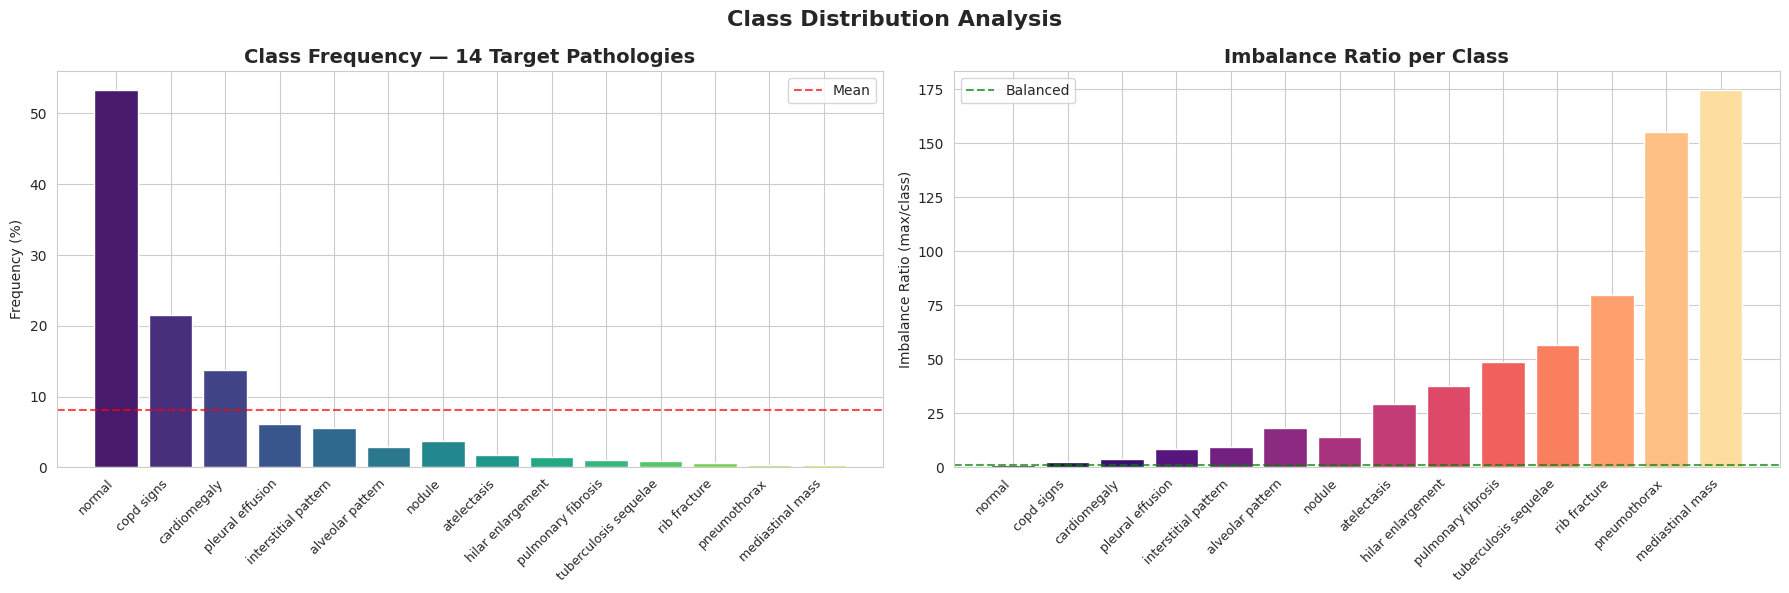

In [13]:
counts    = y.sum(axis=0)
freqs     = counts / len(y)
imbalance = counts.max() / counts

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(range(NUM_CLASSES), freqs * 100, color=sns.color_palette('viridis', NUM_CLASSES))
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel("Frequency (%)")
axes[0].set_title("Class Frequency — 14 Target Pathologies", fontsize=14, fontweight='bold')
axes[0].axhline(y=freqs.mean() * 100, color='red', linestyle='--', alpha=0.7, label='Mean')
axes[0].legend()

axes[1].bar(range(NUM_CLASSES), imbalance, color=sns.color_palette('magma', NUM_CLASSES))
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel("Imbalance Ratio (max/class)")
axes[1].set_title("Imbalance Ratio per Class", fontsize=14, fontweight='bold')
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.7, label='Balanced')
axes[1].legend()

plt.suptitle("Class Distribution Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Nombre de labels par image

Moyenne labels/image : 1.14
Max labels/image     : 6
Images mono-label    : 55,660 (88.9%)


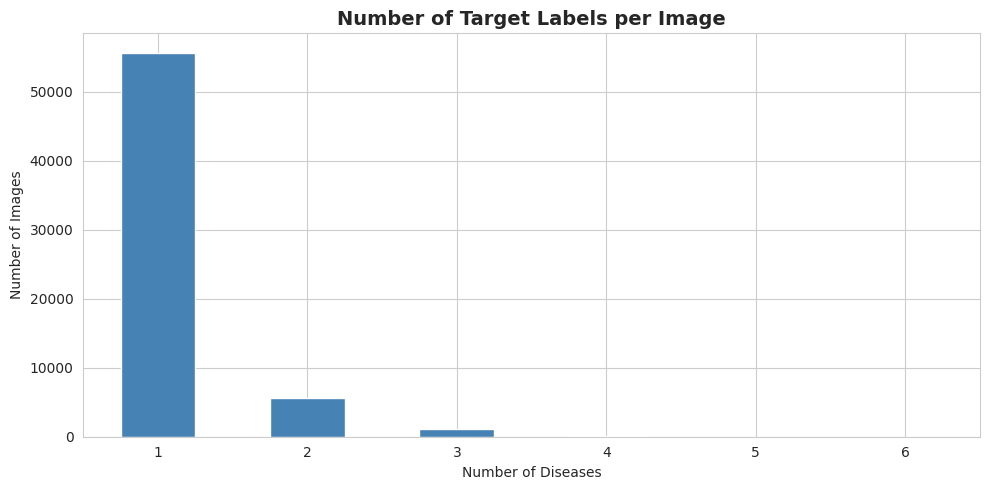

In [14]:
labels_per_image = df_clean['Labels_filtered'].apply(len)
print(f"Moyenne labels/image : {labels_per_image.mean():.2f}")
print(f"Max labels/image     : {labels_per_image.max()}")
print(f"Images mono-label    : {(labels_per_image == 1).sum():,} ({(labels_per_image == 1).mean()*100:.1f}%)")

plt.figure(figsize=(10, 5))
labels_per_image.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Number of Target Labels per Image", fontsize=14, fontweight='bold')
plt.xlabel("Number of Diseases"); plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/labels_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3 — Feature engineering & Split patient-level

### 3.1 Métadonnées patients (6 features normalisées)

In [15]:
def build_metadata_features(df_input):
    """Construit un vecteur de 6 métadonnées normalisées par image."""
    meta = pd.DataFrame()
    meta['age_norm']  = (df_input['Age'] - 18) / (100 - 18)
    meta['sex_M']     = (df_input['PatientSex_DICOM'] == 'M').astype(float)
    meta['sex_F']     = (df_input['PatientSex_DICOM'] == 'F').astype(float)
    meta['proj_PA']   = (df_input['Projection'] == 'PA').astype(float)
    meta['proj_AP']   = (df_input['Projection'] == 'AP').astype(float)
    meta['year_norm'] = (df_input['StudyDate_DICOM'].dt.year - 2009) / (2017 - 2009)
    return meta.fillna(0.5)

meta_features = build_metadata_features(df_clean)
N_META = meta_features.shape[1]
print(f"Features métadonnées : {N_META}")
print(meta_features.describe().round(3))

Features métadonnées : 6
        age_norm    sex_M      sex_F    proj_PA    proj_AP  year_norm
count  62624.000  62624.0  62624.000  62624.000  62624.000  62624.000
mean       0.504      0.5      0.499      0.966      0.034      0.404
std        0.211      0.5      0.500      0.182      0.182      0.292
min        0.000      0.0      0.000      0.000      0.000     -0.250
25%        0.354      0.0      0.000      1.000      0.000      0.125
50%        0.524      1.0      0.000      1.000      0.000      0.375
75%        0.671      1.0      1.000      1.000      0.000      0.625
max        1.000      1.0      1.000      1.000      1.000      1.000


### 3.2 Split patient-level 70/15/15 — sans data leakage

In [16]:
patients = df_clean['PatientID'].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.30, random_state=42)
val_patients,   test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)

df_train = df_clean[df_clean['PatientID'].isin(train_patients)].copy()
df_val   = df_clean[df_clean['PatientID'].isin(val_patients)].copy()
df_test  = df_clean[df_clean['PatientID'].isin(test_patients)].copy()

print(f"Train : {len(df_train):,} images ({df_train['PatientID'].nunique():,} patients)")
print(f"Val   : {len(df_val):,}   images ({df_val['PatientID'].nunique():,} patients)")
print(f"Test  : {len(df_test):,}  images ({df_test['PatientID'].nunique():,} patients)")

assert len(set(train_patients) & set(val_patients))  == 0
assert len(set(train_patients) & set(test_patients)) == 0
print("✅ Aucun data leakage patient détecté")

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

y_train = mlb.transform(df_train['Labels_filtered'].tolist())
y_val   = mlb.transform(df_val['Labels_filtered'].tolist())
y_test  = mlb.transform(df_test['Labels_filtered'].tolist())

print(f"\ny_train shape : {y_train.shape}")
print(f"y_val   shape : {y_val.shape}")
print(f"y_test  shape : {y_test.shape}")

Train : 43,878 images (30,963 patients)
Val   : 9,325   images (6,635 patients)
Test  : 9,421  images (6,636 patients)
✅ Aucun data leakage patient détecté

y_train shape : (43878, 14)
y_val   shape : (9325, 14)
y_test  shape : (9421, 14)


### 3.3 Visualisation distribution des splits

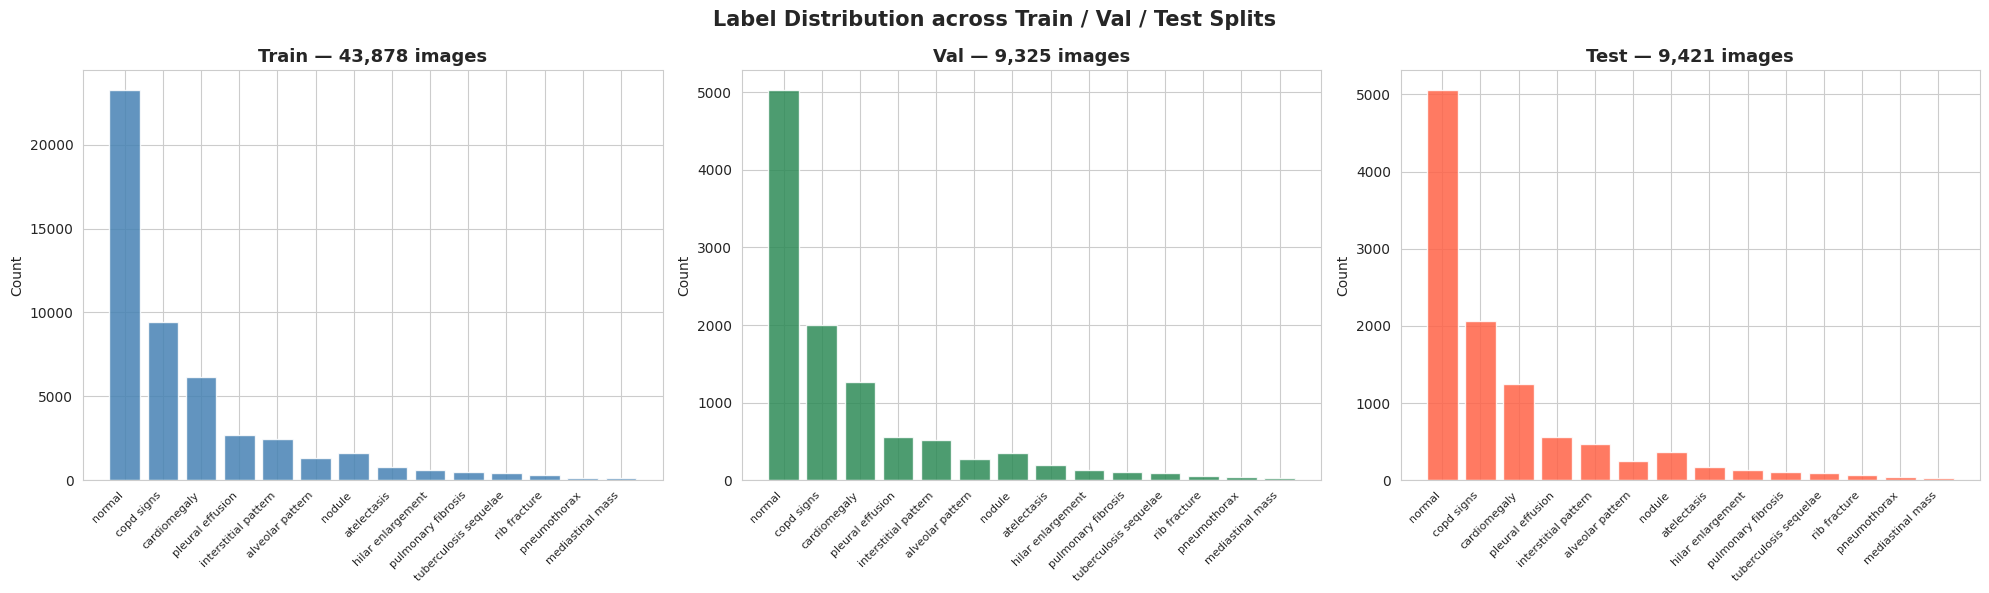

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
splits = [
    (y_train, df_train, 'Train', 'steelblue'),
    (y_val,   df_val,   'Val',   'seagreen'),
    (y_test,  df_test,  'Test',  'tomato'),
]
for ax, (y_s, df_s, name, color) in zip(axes, splits):
    counts_s = y_s.sum(axis=0)
    ax.bar(range(NUM_CLASSES), counts_s, color=color, alpha=0.85)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{name} — {len(df_s):,} images", fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")

plt.suptitle("Label Distribution across Train / Val / Test Splits", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4 — Dataset PyTorch avec CLAHE + DataLoaders

In [18]:
# ── Transformations ───────────────────────────────────────────────────────────
# NOTE : CLAHE est appliqué directement dans __getitem__ avant Torchvision
train_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── CLAHE helper ───────────────────────────────────────────────────────────────
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

class PadChestDataset(Dataset):
    """Dataset PadChest224 multi-label avec CLAHE + métadonnées patient."""
    def __init__(self, df, y_labels, meta_features, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.y_labels  = y_labels.astype(np.float32)
        self.meta      = meta_features.reset_index(drop=True).values.astype(np.float32)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.at[idx, 'ImageID']
        img_path = os.path.join(self.img_dir, img_name)

        try:
            # ── 1. Lecture OpenCV grayscale + CLAHE ──────────────────────────
            img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_cv is None:
                raise ValueError("Image non lisible")
            img_cv = _clahe.apply(img_cv)          # ← amélioration contraste
            img    = Image.fromarray(img_cv)        # → PIL pour Torchvision
        except Exception:
            img = Image.fromarray(np.zeros((224, 224), dtype=np.uint8))

        if self.transform:
            img = self.transform(img)

        meta   = torch.tensor(self.meta[idx])
        labels = torch.tensor(self.y_labels[idx])
        return img, meta, labels

# ── Instanciation ─────────────────────────────────────────────────────────────
meta_train = build_metadata_features(df_train)
meta_val   = build_metadata_features(df_val)
meta_test  = build_metadata_features(df_test)

train_dataset = PadChestDataset(df_train, y_train, meta_train, IMAGES_PATH, train_transform)
val_dataset   = PadChestDataset(df_val,   y_val,   meta_val,   IMAGES_PATH, val_test_transform)
test_dataset  = PadChestDataset(df_test,  y_test,  meta_test,  IMAGES_PATH, val_test_transform)

print(f"Train dataset : {len(train_dataset):,} images")
print(f"Val   dataset : {len(val_dataset):,} images")
print(f"Test  dataset : {len(test_dataset):,} images")

# ── DataLoaders ───────────────────────────────────────────────────────────────
def make_loaders(train_ds, val_ds, test_ds, batch_size=32):
    pin = DEVICE.type == 'cuda'
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=pin, drop_last=True,
        persistent_workers=False, prefetch_factor=2,
    )
    val_loader = DataLoader(
        val_ds, batch_size=64, shuffle=False,
        num_workers=2, pin_memory=pin,
        persistent_workers=False, prefetch_factor=2,
    )
    test_loader = DataLoader(
        test_ds, batch_size=64, shuffle=False,
        num_workers=2, pin_memory=pin,
        persistent_workers=False, prefetch_factor=2,
    )
    print(f"✅ DataLoaders  train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)} batches")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    train_dataset, val_dataset, test_dataset, batch_size=32
)

# Vérification rapide
try:
    imgs, metas, labels = next(iter(train_loader))
    print(f"✅ Batch OK — imgs:{imgs.shape} metas:{metas.shape} labels:{labels.shape}")
except Exception as e:
    print(f"❌ Loader KO : {e} — fallback num_workers=0")
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

Train dataset : 43,878 images
Val   dataset : 9,325 images
Test  dataset : 9,421 images
✅ DataLoaders  train:1371 | val:146 | test:148 batches
✅ Batch OK — imgs:torch.Size([32, 3, 224, 224]) metas:torch.Size([32, 6]) labels:torch.Size([32, 14])


## Phase 5 — Architectures CNN (EfficientNet-B4 + DenseNet121 + métadonnées)

In [19]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("CUDA available :", torch.cuda.is_available())

2.10.0+cu128
12.8
Tesla T4
CUDA available : True


In [20]:
class DenseNet121PadChest(nn.Module):
    """DenseNet121 + branche métadonnées — 14 pathologies cibles."""
    def __init__(self, n_classes=14, n_meta=6, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'densenet121', pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features   # 1024
        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(64, 32), nn.ReLU(inplace=True)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim + 32, 512),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75), nn.Linear(512, n_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in [self.meta_branch, self.classifier]:
            for layer in m.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def forward(self, image, metadata):
        return self.classifier(
            torch.cat([self.backbone(image), self.meta_branch(metadata)], dim=1)
        )
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
    def get_param_groups(self, lr_head=1e-3, lr_backbone=1e-4):
        return [
            {'params': self.backbone.parameters(),    'lr': lr_backbone},
            {'params': self.meta_branch.parameters(), 'lr': lr_head},
            {'params': self.classifier.parameters(),  'lr': lr_head},
        ]


class EfficientNetB4PadChest(nn.Module):
    """EfficientNet-B4 + branche métadonnées — 14 pathologies cibles."""
    def __init__(self, n_classes=14, n_meta=6, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=pretrained,
            num_classes=0, global_pool='avg', drop_rate=0.3
        )
        feat_dim = self.backbone.num_features   # 1792
        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(64, 32), nn.ReLU(inplace=True)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim + 32, 768),
            nn.BatchNorm1d(768), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6), nn.Linear(768, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout * 0.4),
            nn.Linear(256, n_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in [self.meta_branch, self.classifier]:
            for layer in m.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def forward(self, image, metadata):
        return self.classifier(
            torch.cat([self.backbone(image), self.meta_branch(metadata)], dim=1)
        )
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
    def get_param_groups(self, lr_head=1e-3, lr_backbone=1e-4):
        return [
            {'params': self.backbone.parameters(),    'lr': lr_backbone},
            {'params': self.meta_branch.parameters(), 'lr': lr_head},
            {'params': self.classifier.parameters(),  'lr': lr_head},
        ]


def build_model(name, n_classes=14, n_meta=6, pretrained=True):
    models_map = {
        'densenet121'    : DenseNet121PadChest,
        'efficientnet_b4': EfficientNetB4PadChest,
    }
    assert name in models_map, f"Modèle inconnu : {name}"
    model = models_map[name](n_classes, n_meta, pretrained).to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{name}]  {total/1e6:.1f}M params | feat_dim={model.backbone.num_features} | n_classes={n_classes}")
    return model

# Test forward pass
_m    = build_model('efficientnet_b4', n_classes=NUM_CLASSES, n_meta=N_META)
_x    = torch.randn(2, 3, 224, 224).to(DEVICE)
_m_in = torch.randn(2, N_META).to(DEVICE)
print(f"Forward pass test : {_m(_x, _m_in).shape}")   # (2, 14)
del _m, _x, _m_in

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

[efficientnet_b4]  19.2M params | feat_dim=1792 | n_classes=14
Forward pass test : torch.Size([2, 14])


## Phase 6 — Loss adaptée + Trainer avec Mixup & Warmup LR

### 6.1 Focal Loss avec class weights (effective number of samples)

In [21]:
class FocalLoss(nn.Module):
    """
    Focal Loss multi-label pour déséquilibre de classes.
    gamma=2.5 pour pénaliser davantage les exemples difficiles.
    alpha = effective number of samples weights.
    """
    def __init__(self, gamma=2.5, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t  = torch.sigmoid(logits) * targets + (1 - torch.sigmoid(logits)) * (1 - targets)
        loss = ((1 - p_t) ** self.gamma) * bce
        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device)
        return loss.mean()


def compute_pos_weights(y_train, beta=0.9999, clip_max=50.0):
    """Effective number of samples — plus robuste pour classes très rares."""
    counts  = y_train.sum(axis=0)
    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / (eff_num + 1e-8)
    weights = weights / weights.min()
    weights = np.clip(weights, 1.0, clip_max)
    return torch.tensor(weights, dtype=torch.float32)

pos_weights = compute_pos_weights(y_train)

print("Class weights (effective number) :")
for i, label in enumerate(TARGET_DISEASES):
    bar = '█' * min(int(pos_weights[i].item()), 20)
    print(f"  {label:<30} w={pos_weights[i].item():6.2f}  {bar}")

criterion = FocalLoss(gamma=2.5, alpha=pos_weights).to(DEVICE)

Class weights (effective number) :
  normal                         w=  1.00  █
  copd signs                     w=  1.48  █
  cardiomegaly                   w=  1.97  █
  pleural effusion               w=  3.80  ███
  interstitial pattern           w=  4.10  ████
  alveolar pattern               w=  7.41  ███████
  nodule                         w=  6.09  ██████
  atelectasis                    w= 12.22  ████████████
  hilar enlargement              w= 14.87  ██████████████
  pulmonary fibrosis             w= 19.29  ███████████████████
  tuberculosis sequelae          w= 22.79  ████████████████████
  rib fracture                   w= 31.68  ████████████████████
  pneumothorax                   w= 50.00  ████████████████████
  mediastinal mass               w= 50.00  ████████████████████


### 6.2 Visualisation des class weights

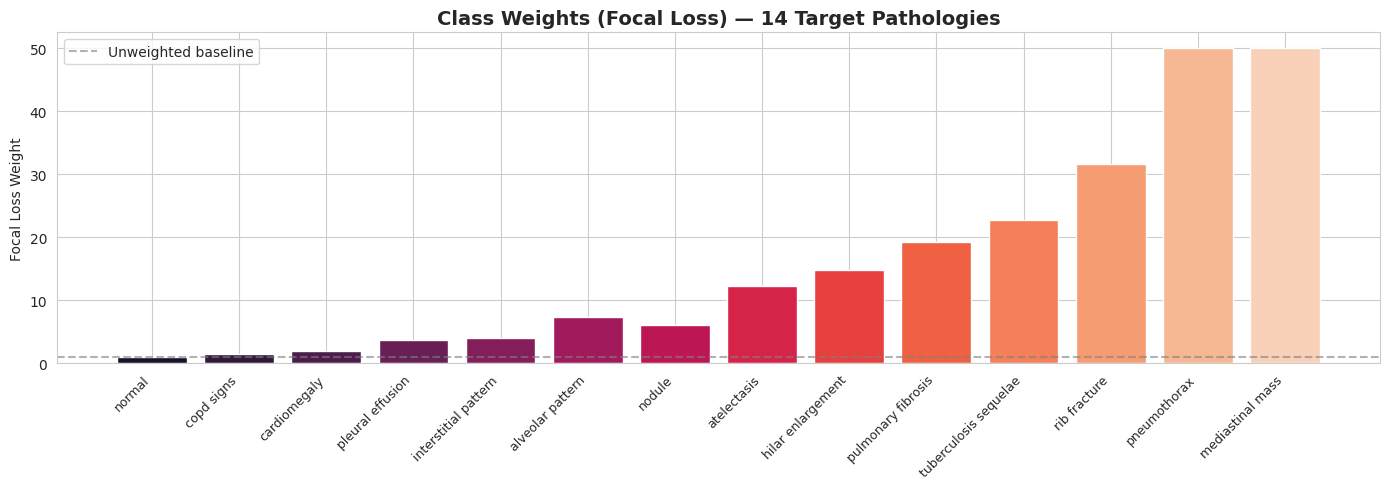

In [22]:
plt.figure(figsize=(14, 5))
plt.bar(range(NUM_CLASSES), pos_weights.numpy(), color=sns.color_palette('rocket', NUM_CLASSES))
plt.xticks(range(NUM_CLASSES), TARGET_DISEASES, rotation=45, ha='right', fontsize=9)
plt.ylabel("Focal Loss Weight")
plt.title("Class Weights (Focal Loss) — 14 Target Pathologies", fontsize=14, fontweight='bold')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6, label='Unweighted baseline')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Trainer — Mixup + Warmup LR + ReduceLROnPlateau + TTA

In [23]:
TRAIN_CONFIG = {
    'epochs'        : 50,
    'lr_head'       : 3e-4,
    'lr_backbone'   : 5e-5,
    'weight_decay'  : 1e-3,
    'patience'      : 10,
    'unfreeze_epoch': 3,
    'warmup_epochs' : 3,       # ← Nouveau : linear warmup
    'mixup_alpha'   : 0.3,     # ← Nouveau : Mixup multi-label
    'tta_n'         : 4,       # ← Nouveau : TTA passes at inference
    'checkpoint_dir': '/kaggle/working/checkpoints',
}
os.makedirs(TRAIN_CONFIG['checkpoint_dir'], exist_ok=True)


def compute_metrics(y_true, y_probs, thresholds=None):
    """Calcule AUC, mAP, F1 macro/micro. thresholds = array par classe (optionnel)."""
    aucs, aps = [], []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0:
            aucs.append(roc_auc_score(y_true[:, i], y_probs[:, i]))
            aps.append(average_precision_score(y_true[:, i], y_probs[:, i]))
    if thresholds is None:
        thresholds = np.full(y_true.shape[1], 0.5)
    y_pred = (y_probs >= thresholds).astype(int)
    return {
        'auc_macro': np.mean(aucs) if aucs else 0.0,
        'map'      : np.mean(aps)  if aps  else 0.0,
        'f1_macro' : f1_score(y_true, y_pred, average='macro',  zero_division=0),
        'f1_micro' : f1_score(y_true, y_pred, average='micro',  zero_division=0),
    }


# ── TTA transform (flip H + légère rotation) ──────────────────────────────────
tta_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class PadChestTrainer:
    def __init__(self, model, model_name, train_loader, val_loader, criterion, config):
        self.model        = model
        self.model_name   = model_name
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.criterion    = criterion
        self.config       = config
        self.history      = []
        self.best_auc     = 0.0
        self.patience_ctr = 0
        self.scaler       = GradScaler(AMP_DEVICE, enabled=USE_AMP)
        self.ckpt_path    = f"{config['checkpoint_dir']}/best_{model_name}.pt"
        self.meta_path    = self.ckpt_path.replace('.pt', '_meta.json')
        self.model.freeze_backbone()
        self._build_optimizer(phase=1)

    def _build_optimizer(self, phase):
        if phase == 1:
            params = filter(lambda p: p.requires_grad, self.model.parameters())
            self.optimizer = torch.optim.AdamW(
                params, lr=self.config['lr_head'],
                weight_decay=self.config['weight_decay']
            )
        else:
            self.optimizer = torch.optim.AdamW(
                self.model.get_param_groups(
                    self.config['lr_head'], self.config['lr_backbone']
                ),
                weight_decay=self.config['weight_decay']
            )
        # ── Warmup LR (phase 1) puis ReduceLROnPlateau (phase 2) ─────────────
        self.scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
            self.optimizer,
            start_factor=0.1, end_factor=1.0,
            total_iters=self.config['warmup_epochs']
        )
        self.scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='max', patience=3, factor=0.5, min_lr=1e-6
        )

    def _mixup_batch(self, imgs, labels):
        """Mixup multi-label : mélange deux images et leurs labels."""
        alpha = self.config['mixup_alpha']
        lam   = np.random.beta(alpha, alpha)
        idx   = torch.randperm(imgs.size(0), device=imgs.device)
        imgs_mix   = lam * imgs   + (1 - lam) * imgs[idx]
        labels_mix = lam * labels + (1 - lam) * labels[idx]
        return imgs_mix, labels_mix

    def _train_epoch(self):
        self.model.train()
        total_loss = 0.0; n = 0
        for imgs, metas, labels in self.train_loader:
            imgs, metas, labels = (
                imgs.to(DEVICE, non_blocking=True),
                metas.to(DEVICE, non_blocking=True),
                labels.to(DEVICE, non_blocking=True)
            )
            # ── Mixup ─────────────────────────────────────────────────────────
            imgs, labels = self._mixup_batch(imgs, labels)

            self.optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                loss = self.criterion(self.model(imgs, metas), labels)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            total_loss += loss.item(); n += 1
        return total_loss / max(n, 1)

    @torch.no_grad()
    def _eval_epoch(self, loader):
        self.model.eval()
        all_probs, all_labels, total_loss = [], [], 0.0
        for imgs, metas, labels in loader:
            imgs, metas, labels = (
                imgs.to(DEVICE, non_blocking=True),
                metas.to(DEVICE, non_blocking=True),
                labels.to(DEVICE, non_blocking=True)
            )
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                logits = self.model(imgs, metas)
                loss   = self.criterion(logits, labels)
            total_loss  += loss.item()
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
        y_probs = np.vstack(all_probs)
        y_true  = np.vstack(all_labels)
        metrics = compute_metrics(y_true, y_probs)
        metrics['loss'] = total_loss / len(loader)
        return metrics, y_probs, y_true

    def train(self):
        cfg = self.config
        backbone_unfrozen = False
        print(f"\n{'='*60}")
        print(f"Entraînement {self.model_name} — {DEVICE}")
        print(f"Mixup α={cfg['mixup_alpha']} | Warmup {cfg['warmup_epochs']} epochs | Patience {cfg['patience']}")
        print(f"{'='*60}")

        for epoch in range(1, cfg['epochs'] + 1):
            t0 = time.time()

            # ── Unfreeze backbone ─────────────────────────────────────────────
            if epoch == cfg['unfreeze_epoch'] and not backbone_unfrozen:
                self.model.unfreeze_backbone()
                self._build_optimizer(phase=2)
                backbone_unfrozen = True
                print(f"  [Epoch {epoch}] 🔓 Backbone dégelé — optimizer reconstruit")

            train_loss           = self._train_epoch()
            val_metrics, yp, yt  = self._eval_epoch(self.val_loader)

            # ── Scheduler step ────────────────────────────────────────────────
            if epoch <= cfg['warmup_epochs']:
                self.scheduler_warmup.step()
            else:
                self.scheduler_plateau.step(val_metrics['auc_macro'])

            lr  = self.optimizer.param_groups[-1]['lr']
            log = {
                'epoch': epoch, 'train_loss': round(train_loss, 4),
                **{f'val_{k}': round(float(v), 4) for k, v in val_metrics.items()},
                'lr': round(lr, 7), 'time_s': round(time.time() - t0, 1)
            }
            self.history.append(log)
            flag = '✅' if val_metrics['auc_macro'] > self.best_auc else '  '
            print(f"Ep {epoch:02d}/{cfg['epochs']} {flag} "
                  f"loss {train_loss:.4f}→{val_metrics['loss']:.4f} "
                  f"AUC {val_metrics['auc_macro']:.4f} "
                  f"mAP {val_metrics['map']:.4f} "
                  f"F1 {val_metrics['f1_macro']:.4f} "
                  f"lr {lr:.1e} {log['time_s']:.0f}s")

            if val_metrics['auc_macro'] > self.best_auc:
                self.best_auc     = val_metrics['auc_macro']
                self.patience_ctr = 0
                torch.save(self.model.state_dict(), self.ckpt_path)
                with open(self.meta_path, 'w') as f:
                    json.dump({
                        'epoch': epoch, 'best_auc': float(self.best_auc),
                        'val_metrics': {k: float(v) for k, v in val_metrics.items()},
                        'target_diseases': TARGET_DISEASES,
                        'n_classes': NUM_CLASSES, 'n_meta': N_META
                    }, f, indent=2)
                print(f"  ✅ Checkpoint sauvegardé (AUC={self.best_auc:.4f})")
            else:
                self.patience_ctr += 1
                if self.patience_ctr >= cfg['patience']:
                    print(f"\n⏹️  Early stopping epoch {epoch}")
                    break

        with open(f"{cfg['checkpoint_dir']}/{self.model_name}_history.json", 'w') as f:
            json.dump(self.history, f, indent=2)
        print(f"\nBest val AUC : {self.best_auc:.4f}")
        return self.best_auc

    @torch.no_grad()
    def _tta_predict(self, img_tensors, metas, n_aug):
        """TTA : moyenne de n_aug passes avec augmentations aléatoires."""
        all_preds = []
        for _ in range(n_aug):
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                logits = self.model(img_tensors, metas)
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
        return np.mean(all_preds, axis=0)

    def evaluate_test(self, test_loader, use_tta=True):
        """Évaluation sur le test set avec chargement du meilleur checkpoint."""
        # ── 1. Charger le MEILLEUR checkpoint ────────────────────────────────
        self.model.load_state_dict(
            torch.load(self.ckpt_path, map_location=DEVICE, weights_only=True)
        )
        self.model.eval()
        with open(self.meta_path) as f:
            meta = json.load(f)
        print(f"\nCheckpoint chargé — epoch {meta['epoch']} | val AUC {meta['best_auc']:.4f}")

        n_tta = self.config['tta_n'] if use_tta else 1
        if use_tta:
            print(f"TTA activé : {n_tta} passes")

        all_probs, all_labels, total_loss = [], [], 0.0
        for imgs, metas_b, labels in test_loader:
            imgs, metas_b, labels = (
                imgs.to(DEVICE, non_blocking=True),
                metas_b.to(DEVICE, non_blocking=True),
                labels.to(DEVICE, non_blocking=True)
            )
            if use_tta:
                probs = self._tta_predict(imgs, metas_b, n_tta)
            else:
                with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                    logits = self.model(imgs, metas_b)
                    loss   = self.criterion(logits, labels)
                total_loss += loss.item()
                probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

        y_probs = np.vstack(all_probs)
        y_true  = np.vstack(all_labels)
        metrics = compute_metrics(y_true, y_probs)
        if not use_tta:
            metrics['loss'] = total_loss / len(test_loader)

        print(f"\n{'─'*50}\nTEST SET — {self.model_name} (TTA={use_tta})\n{'─'*50}")
        for k, v in metrics.items():
            print(f"  {k:<15} : {v:.4f}")

        print(f"\nAUC par pathologie :")
        for i, label in enumerate(TARGET_DISEASES):
            if y_true[:, i].sum() > 0:
                auc = roc_auc_score(y_true[:, i], y_probs[:, i])
                bar = '█' * int(auc * 20)
                print(f"  {label:<30} {auc:.4f}  {bar}")

        return metrics, y_probs, y_true

### 6.4 Lancement de l'entraînement — EfficientNet-B4

In [24]:
# ── Entraîner EfficientNet-B4 (backbone plus puissant que DenseNet121) ────────
model   = build_model('efficientnet_b4', n_classes=NUM_CLASSES, n_meta=N_META)
trainer = PadChestTrainer(
    model, 'efficientnet_b4', train_loader, val_loader, criterion, TRAIN_CONFIG
)
best_auc = trainer.train()

# ── Évaluation test avec TTA ─────────────────────────────────────────────────
test_metrics, y_probs_test, y_true_test = trainer.evaluate_test(test_loader, use_tta=True)

[efficientnet_b4]  19.2M params | feat_dim=1792 | n_classes=14

Entraînement efficientnet_b4 — cuda
Mixup α=0.3 | Warmup 3 epochs | Patience 10


[ WARN:0@326.677] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@496.630] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@688.241] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 01/50 ✅ loss 0.5118→0.2328 AUC 0.6594 mAP 0.1430 F1 0.1078 lr 1.2e-04 462s
  ✅ Checkpoint sauvegardé (AUC=0.6594)


[ WARN:0@785.808] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@929.345] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@959.407] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 02/50 ✅ loss 0.2176→0.2473 AUC 0.7348 mAP 0.1786 F1 0.1038 lr 2.1e-04 248s
  ✅ Checkpoint sauvegardé (AUC=0.7348)
  [Epoch 3] 🔓 Backbone dégelé — optimizer reconstruit


...

Ep 43/50    loss 0.1227→0.1742 AUC 0.8487 mAP 0.3617 F1 0.3034 lr 3.0e-05 357s


[ WARN:0@15825.422] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@15938.805] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@15959.698] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 44/50    loss 0.1228→0.1723 AUC 0.8486 mAP 0.3632 F1 0.3099 lr 3.0e-05 358s

⏹️  Early stopping epoch 44

Best val AUC : 0.8576

Checkpoint chargé — epoch 34 | val AUC 0.8576
TTA activé : 4 passes


[ WARN:0@16009.050] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012989926673512011074122523403_00-163-058.png'): can't open/read file: check file path/integrity



──────────────────────────────────────────────────
TEST SET — efficientnet_b4 (TTA=True)
──────────────────────────────────────────────────
  auc_macro       : 0.8551
  map             : 0.3538
  f1_macro        : 0.2710
  f1_micro        : 0.6619

AUC par pathologie :
  normal                         0.8970  █████████████████
  copd signs                     0.8521  █████████████████
  cardiomegaly                   0.9204  ██████████████████
  pleural effusion               0.9623  ███████████████████
  interstitial pattern           0.8800  █████████████████
  alveolar pattern               0.9099  ██████████████████
  nodule                         0.6890  █████████████
  atelectasis                    0.8948  █████████████████
  hilar enlargement              0.6991  █████████████
  pulmonary fibrosis             0.9671  ███████████████████
  tuberculosis sequelae          0.9285  ██████████████████
  rib fracture                   0.7389  ██████████████
  pneumothorax           

## Phase 7 — Seuils optimaux par classe (F1-optimal sur val set)

In [25]:
@torch.no_grad()
def get_val_probs(model, loader):
    """Récupère les probabilités sur le val set depuis le meilleur checkpoint."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, metas, labels in loader:
        imgs, metas = imgs.to(DEVICE), metas.to(DEVICE)
        with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            logits = model(imgs, metas)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)


def find_optimal_thresholds(y_true, y_probs, thresholds=None):
    """Cherche le seuil F1-optimal par classe sur le val set."""
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.02)

    best_thresholds = []
    print(f"\n{'Label':<30} {'Best threshold':>15} {'Best F1':>10}")
    print("-" * 58)

    for i, label in enumerate(TARGET_DISEASES):
        if y_true[:, i].sum() == 0:
            best_thresholds.append(0.5)
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (y_probs[:, i] >= t).astype(int)
            f1    = f1_score(y_true[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
        print(f"  {label:<30} {best_t:>14.2f} {best_f1:>10.4f}")

    return np.array(best_thresholds)


# ── Récupérer les probs val depuis le meilleur checkpoint ────────────────────
val_probs, val_true = get_val_probs(trainer.model, val_loader)

# ── Trouver les seuils optimaux ──────────────────────────────────────────────
optimal_thresholds = find_optimal_thresholds(val_true, val_probs)

# ── Réévaluer le test avec seuils optimaux ───────────────────────────────────
y_pred_optimal = (y_probs_test >= optimal_thresholds).astype(int)
y_pred_default = (y_probs_test >= 0.5).astype(int)

f1_default = f1_score(y_true_test, y_pred_default, average='macro',  zero_division=0)
f1_optimal = f1_score(y_true_test, y_pred_optimal, average='macro',  zero_division=0)
f1_opt_mic = f1_score(y_true_test, y_pred_optimal, average='micro',  zero_division=0)

print(f"\n{'─'*50}")
print(f"F1 macro  seuil=0.5    : {f1_default:.4f}")
print(f"F1 macro  seuil optimal: {f1_optimal:.4f}  ← amélioration")
print(f"F1 micro  seuil optimal: {f1_opt_mic:.4f}")

# ── Sauvegarder les seuils ───────────────────────────────────────────────────
np.save('/kaggle/working/optimal_thresholds.npy', optimal_thresholds)
print("\n✅ Seuils sauvegardés → optimal_thresholds.npy")

[ WARN:0@16073.415] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity



Label                           Best threshold    Best F1
----------------------------------------------------------
  normal                                   0.49     0.8365
  copd signs                               0.43     0.6081
  cardiomegaly                             0.43     0.6318
  pleural effusion                         0.49     0.6753
  interstitial pattern                     0.39     0.4077
  alveolar pattern                         0.39     0.4006
  nodule                                   0.31     0.1397
  atelectasis                              0.41     0.3141
  hilar enlargement                        0.31     0.0769
  pulmonary fibrosis                       0.47     0.4390
  tuberculosis sequelae                    0.49     0.4675
  rib fracture                             0.39     0.1304
  pneumothorax                             0.53     0.1364
  mediastinal mass                         0.27     0.0364

──────────────────────────────────────────────────
F1 m

## Phase 8 — Visualisations post-entraînement

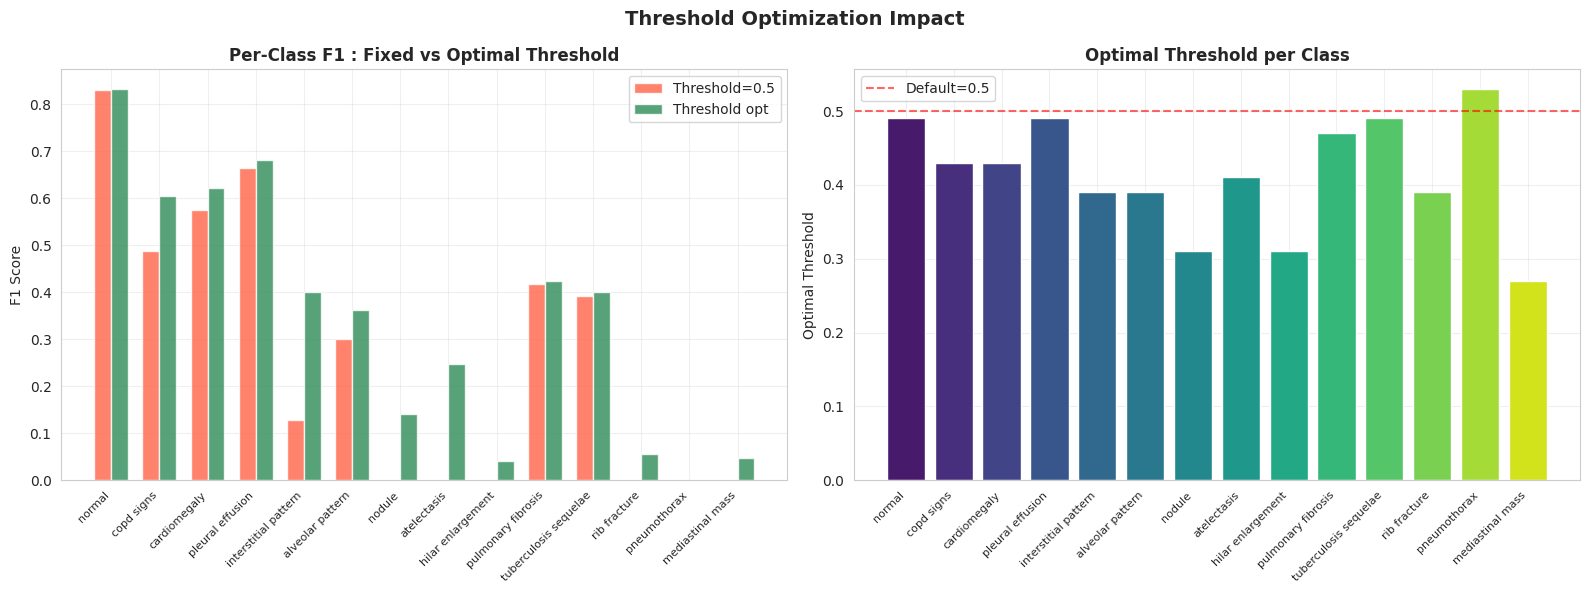

In [26]:
# ── Comparaison F1 seuil 0.5 vs optimal ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

f1_default_per = [f1_score(y_true_test[:, i], y_pred_default[:, i], zero_division=0)
                  for i in range(NUM_CLASSES)]
f1_optimal_per = [f1_score(y_true_test[:, i], y_pred_optimal[:, i], zero_division=0)
                  for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES); w = 0.35
axes[0].bar(x - w/2, f1_default_per, w, label='Threshold=0.5', color='tomato',   alpha=0.8)
axes[0].bar(x + w/2, f1_optimal_per, w, label='Threshold opt', color='seagreen', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("Per-Class F1 : Fixed vs Optimal Threshold", fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(NUM_CLASSES), optimal_thresholds,
            color=sns.color_palette('viridis', NUM_CLASSES))
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Default=0.5')
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel("Optimal Threshold")
axes[1].set_title("Optimal Threshold per Class", fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Threshold Optimization Impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Courbes d'entraînement

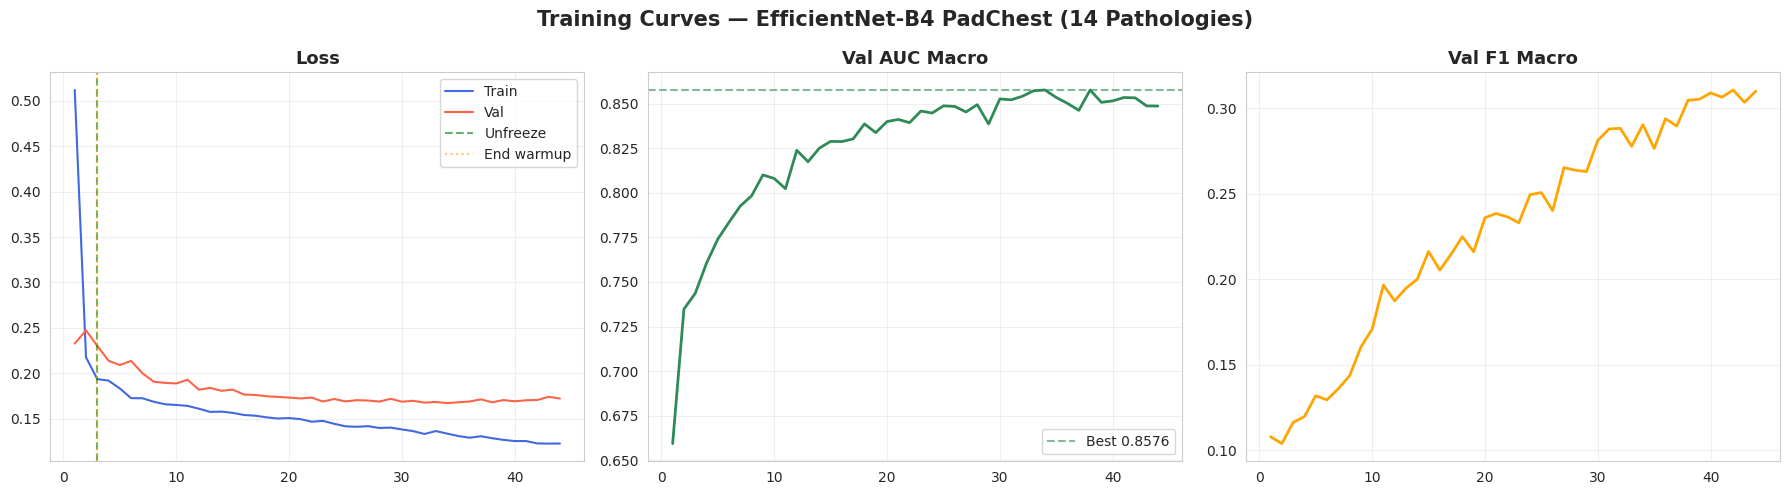

In [27]:
history    = trainer.history
epochs_log = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_log, [h['train_loss']    for h in history], label='Train', color='royalblue')
axes[0].plot(epochs_log, [h['val_loss']      for h in history], label='Val',   color='tomato')
axes[0].axvline(TRAIN_CONFIG['unfreeze_epoch'], color='green', linestyle='--', alpha=0.6, label='Unfreeze')
axes[0].axvline(TRAIN_CONFIG['warmup_epochs'],  color='orange', linestyle=':', alpha=0.6, label='End warmup')
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_log, [h['val_auc_macro'] for h in history], color='seagreen', linewidth=2)
axes[1].axhline(best_auc, color='seagreen', linestyle='--', alpha=0.6, label=f'Best {best_auc:.4f}')
axes[1].set_title('Val AUC Macro', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_log, [h['val_f1_macro']  for h in history], color='orange', linewidth=2)
axes[2].set_title('Val F1 Macro', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle(f"Training Curves — EfficientNet-B4 PadChest (14 Pathologies)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 AUC par pathologie (test set)

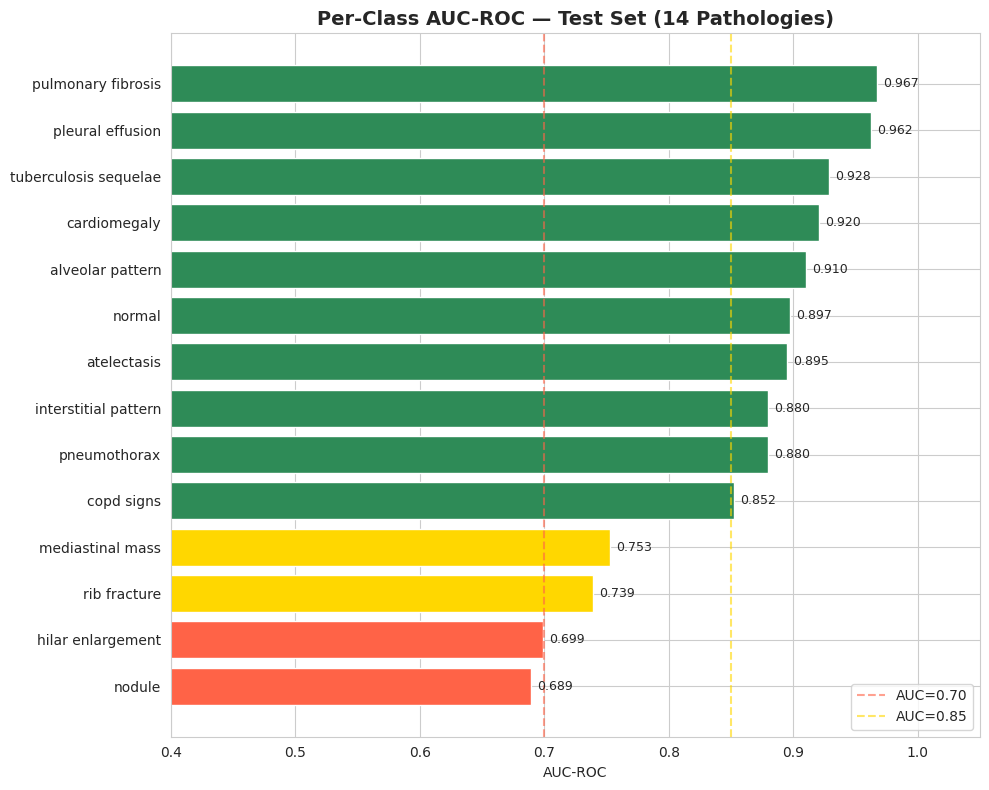

In [28]:
aucs_per_class = []
for i, label in enumerate(TARGET_DISEASES):
    if y_true_test[:, i].sum() > 0:
        auc = roc_auc_score(y_true_test[:, i], y_probs_test[:, i])
        aucs_per_class.append({'Disease': label, 'AUC': auc})
    else:
        aucs_per_class.append({'Disease': label, 'AUC': np.nan})

auc_df = pd.DataFrame(aucs_per_class).sort_values('AUC', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['tomato' if a < 0.7 else 'gold' if a < 0.85 else 'seagreen'
          for a in auc_df['AUC'].fillna(0)]
plt.barh(auc_df['Disease'], auc_df['AUC'], color=colors)
plt.axvline(x=0.7,  color='tomato',   linestyle='--', alpha=0.6, label='AUC=0.70')
plt.axvline(x=0.85, color='gold',     linestyle='--', alpha=0.6, label='AUC=0.85')
plt.xlabel("AUC-ROC")
plt.title("Per-Class AUC-ROC — Test Set (14 Pathologies)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right'); plt.xlim(0.4, 1.05)
for i, (auc, label) in enumerate(zip(auc_df['AUC'], auc_df['Disease'])):
    if not np.isnan(auc):
        plt.text(auc + 0.005, i, f'{auc:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/auc_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Courbes ROC — 14 pathologies

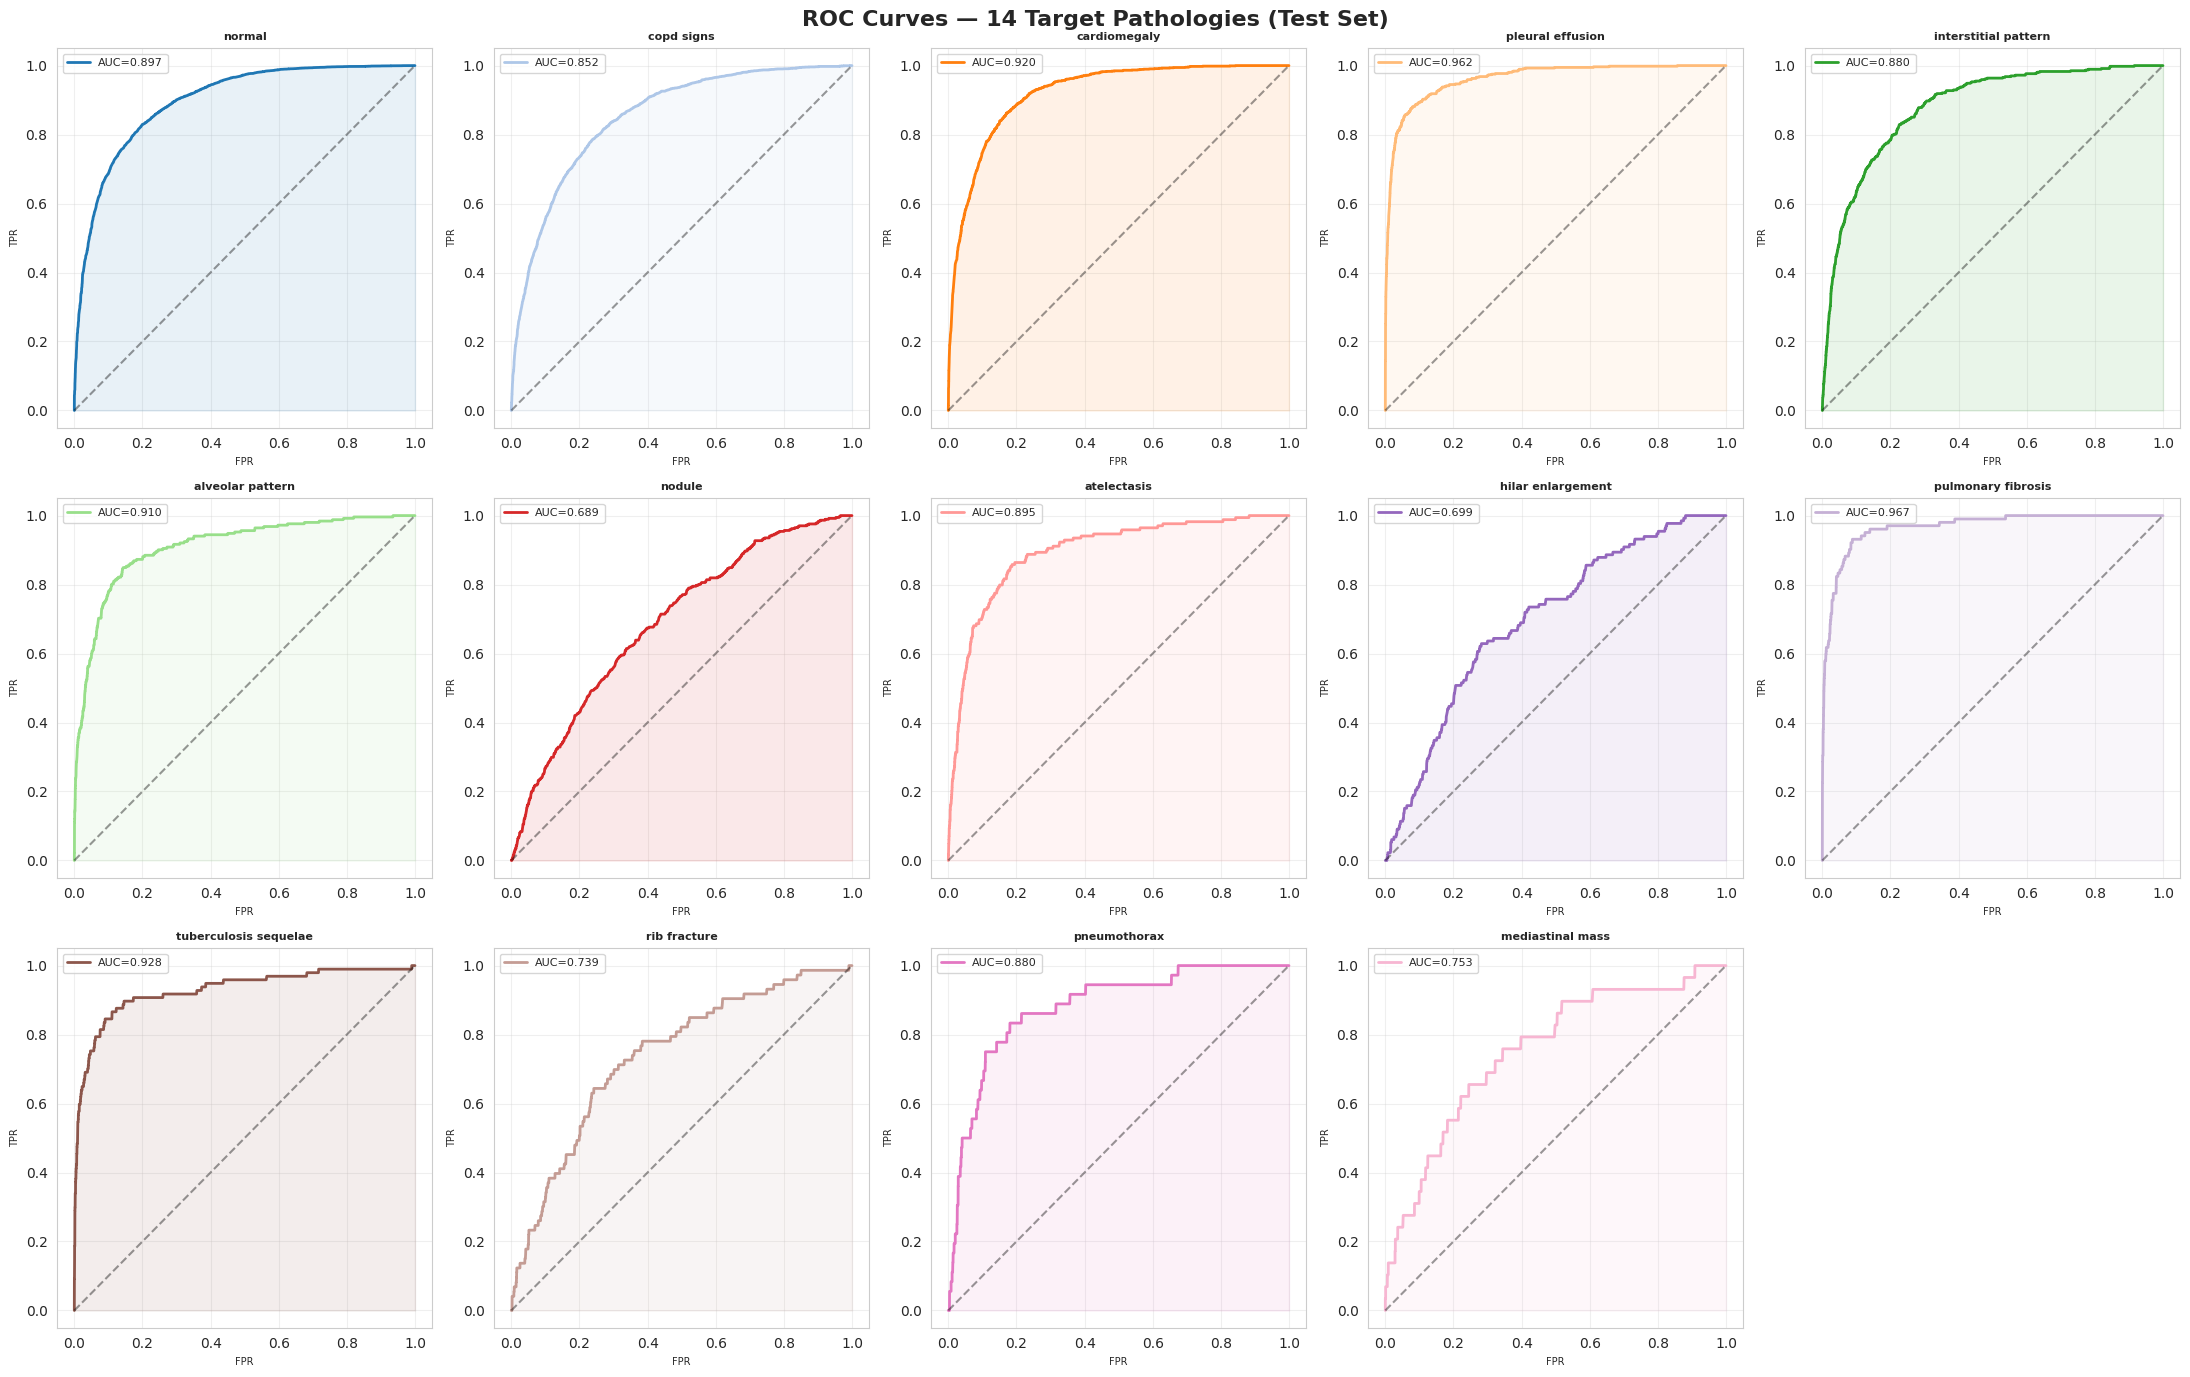

In [29]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(3, 5, figsize=(22, 14))
axes = axes.flatten()
colors_roc = sns.color_palette('tab20', NUM_CLASSES)

for i, (label, color) in enumerate(zip(TARGET_DISEASES, colors_roc)):
    ax = axes[i]
    if y_true_test[:, i].sum() > 0:
        fpr, tpr, _ = roc_curve(y_true_test[:, i], y_probs_test[:, i])
        auc_val      = roc_auc_score(y_true_test[:, i], y_probs_test[:, i])
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'AUC={auc_val:.3f}')
        ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
    ax.grid(alpha=0.3)

for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis('off')

plt.suptitle("ROC Curves — 14 Target Pathologies (Test Set)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Matrices de confusion (seuils optimaux)

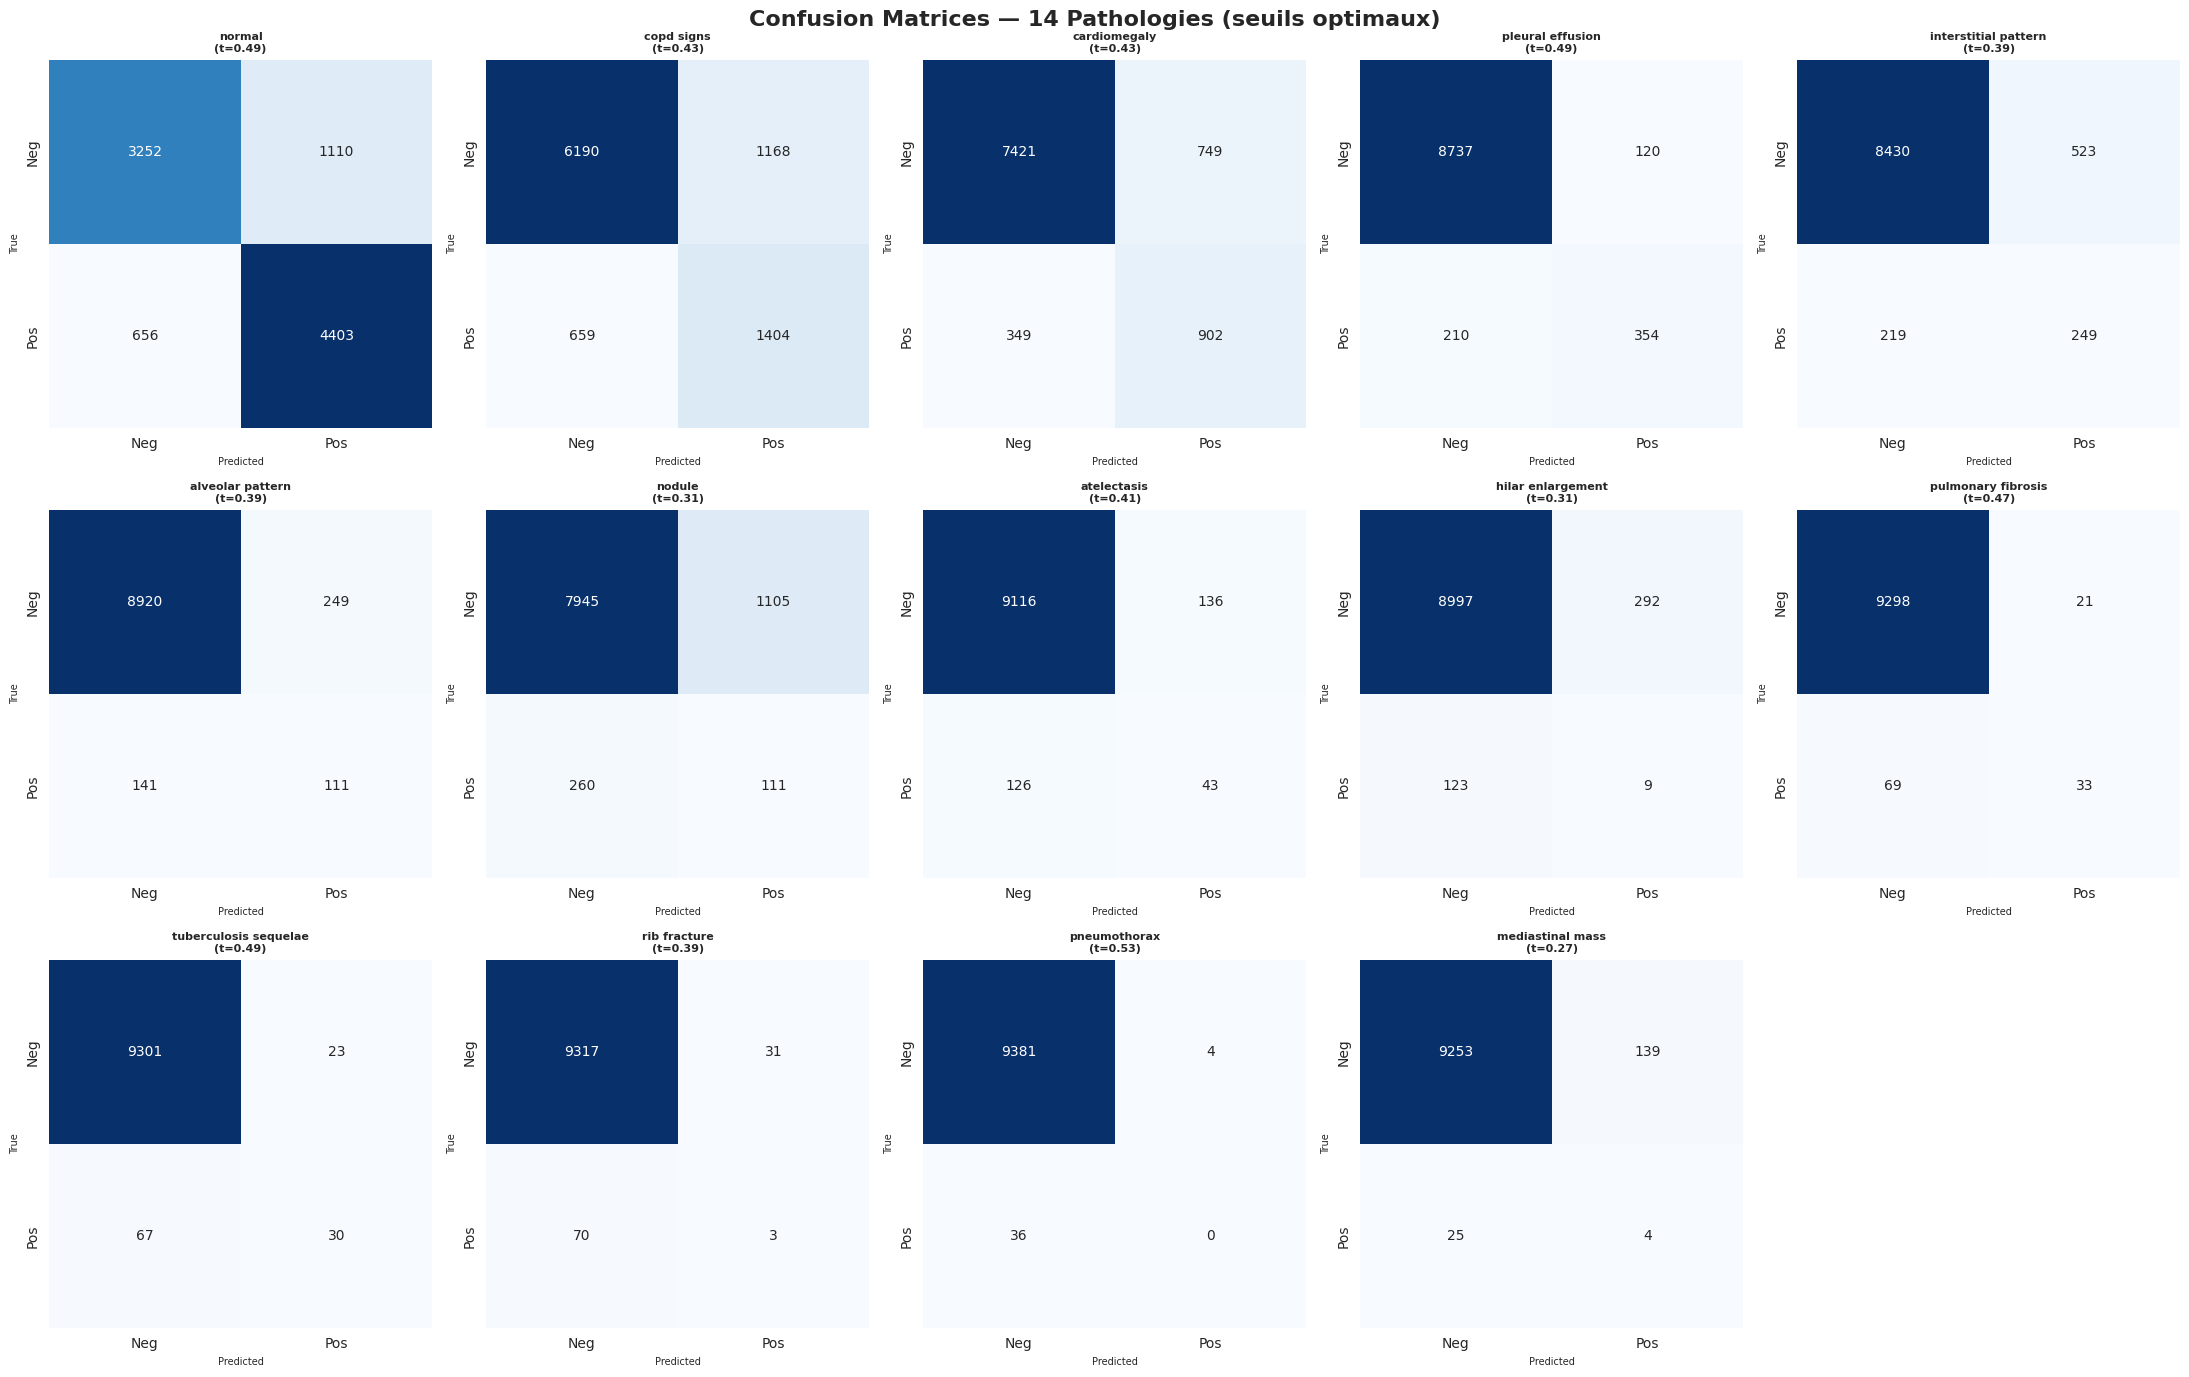

In [30]:
fig, axes = plt.subplots(3, 5, figsize=(22, 14))
axes = axes.flatten()

for i, label in enumerate(TARGET_DISEASES):
    ax = axes[i]
    if y_true_test[:, i].sum() > 0:
        cm = confusion_matrix(y_true_test[:, i], y_pred_optimal[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
                    ax=ax, cbar=False)
        ax.set_title(f"{label}\n(t={optimal_thresholds[i]:.2f})", fontsize=8, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=7); ax.set_ylabel('True', fontsize=7)
    else:
        ax.axis('off')

for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis('off')

plt.suptitle("Confusion Matrices — 14 Pathologies (seuils optimaux)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Rapport de classification final (seuils optimaux)

In [31]:
print("\n" + "="*65)
print("RÉSULTATS FINAUX — TEST SET (EfficientNet-B4 + TTA + Seuils optimaux)")
print("="*65)

# Métriques avec seuils optimaux
final_metrics = {
    'auc_macro'   : float(np.mean([roc_auc_score(y_true_test[:, i], y_probs_test[:, i])
                                   for i in range(NUM_CLASSES) if y_true_test[:, i].sum() > 0])),
    'map'         : float(np.mean([average_precision_score(y_true_test[:, i], y_probs_test[:, i])
                                   for i in range(NUM_CLASSES) if y_true_test[:, i].sum() > 0])),
    'f1_macro_opt': float(f1_score(y_true_test, y_pred_optimal, average='macro',  zero_division=0)),
    'f1_micro_opt': float(f1_score(y_true_test, y_pred_optimal, average='micro',  zero_division=0)),
    'f1_macro_05' : float(f1_score(y_true_test, y_pred_default, average='macro',  zero_division=0)),
}

for k, v in final_metrics.items():
    print(f"  {k:<20} : {v:.4f}")

print("\n" + classification_report(
    y_true_test, y_pred_optimal,
    target_names=TARGET_DISEASES,
    zero_division=0
))

# Sauvegarder les résultats finaux
with open('/kaggle/working/final_results.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)
print("\n✅ Résultats sauvegardés → final_results.json")


RÉSULTATS FINAUX — TEST SET (EfficientNet-B4 + TTA + Seuils optimaux)
  auc_macro            : 0.8551
  map                  : 0.3538
  f1_macro_opt         : 0.3472
  f1_micro_opt         : 0.6382
  f1_macro_05          : 0.2710

                       precision    recall  f1-score   support

               normal       0.80      0.87      0.83      5059
           copd signs       0.55      0.68      0.61      2063
         cardiomegaly       0.55      0.72      0.62      1251
     pleural effusion       0.75      0.63      0.68       564
 interstitial pattern       0.32      0.53      0.40       468
     alveolar pattern       0.31      0.44      0.36       252
               nodule       0.09      0.30      0.14       371
          atelectasis       0.24      0.25      0.25       169
    hilar enlargement       0.03      0.07      0.04       132
   pulmonary fibrosis       0.61      0.32      0.42       102
tuberculosis sequelae       0.57      0.31      0.40        97
         ri